# Personal Information
Name: **Ruben Curiël**

StudentID: **12727431**

Email: [**rzff.curiel@gmail.com**](youremail@student.uva.nl)

Submitted on: **23.3.2025**

Github: https://github.com/rzff/MsCThesisRubenCuriel2024/tree/main/Code

# Data Context
**In this section you should introduce the datasources and datasets which you will be working with. Explain where they are from as well as their domain. Give an overview of what the context of the data is. You should not spend more than 1 to 2 paragraphs here as the core information will be in the next section.**

**CBS**
- Labor participation
- GDP Composition
- Housing
- Energy Prices

**World Bank**
- Commodity Price Data (The Pink Sheet)

**KNMI**
- Daily temperature
- precipitation
-  wind speed
**Copernicus Climate Datastore**
- SIC
- SC
- SST
- Nao Variablity

**ENTSOE**
- Load Consumption




In [12]:
import pandas as pd
import re
from ydata_profiling import ProfileReport
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, pearsonr  # Keep this if needed
import os
import netCDF4 as nc
import pandas as pd
import datetime
from sklearn.decomposition import PCA
import numpy as np
import datetime
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from prophet import Prophet
import warnings
import math
from math import sqrt
import time
warnings.filterwarnings("ignore")



def Create_Hist_Normal_Plot_With_Stats_Outliers(df):
    # Select numeric columns only
    numeric_cols = df.select_dtypes(include=['number']).columns
    num_cols = len(numeric_cols)
    
    if num_cols == 0:
        print("No numeric columns to plot.")
        return

    # Create subplots in a single column layout
    fig, axes = plt.subplots(num_cols, 1, figsize=(8, num_cols * 4))
    
    # If there's only one plot, put it in a list for consistency.
    if num_cols == 1:
        axes = [axes]
    
    for i, col in enumerate(numeric_cols):
        # Convert column values to numeric and drop non-convertible values
        data = pd.to_numeric(df[col], errors='coerce').dropna()
        if data.empty:
            axes[i].text(0.5, 0.5, f'No valid numeric data in {col}', ha='center')
            axes[i].set_title(f'Histogram for {col}')
            continue

        # Compute basic statistics
        mean = data.mean()
        median = data.median()
        std = data.std()
        
        # Identify outliers using the IQR method
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_count = len(outliers)
        
        # Plot the histogram (density normalized)
        axes[i].hist(data, bins=30, density=True, alpha=0.6, color='gray', edgecolor='black')
        
        # Plot the normal curve based on the computed mean and std
        xmin, xmax = data.min(), data.max()
        x = np.linspace(xmin, xmax, 100)
        p = stats.norm.pdf(x, mean, std)
        axes[i].plot(x, p, 'b-', linewidth=2, label='Normal Curve')
        
        # Plot vertical dashed lines for mean and median
        axes[i].axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label='Mean')
        axes[i].axvline(median, color='orange', linestyle='dashed', linewidth=1.5, label='Median')
        
        # Perform Shapiro–Wilk test if there are enough data points (at least 3)
        if len(data) >= 3:
            shapiro_stat, shapiro_p = stats.shapiro(data)
            shapiro_text = f"Shapiro: stat={shapiro_stat:.2f}, p={shapiro_p:.4f}"
        else:
            shapiro_text = "Shapiro: Not enough data"
        
        # Create annotation text that includes the statistics and outlier count
        stats_text = f"Mean: {mean:.2f}, Median: {median:.2f}, Std: {std:.2f}"
        outlier_text = f"Outliers: {outlier_count}"
        annotation_text = f"{stats_text}\n{outlier_text}\n{shapiro_text}"
        
        # Annotate below the plot with extra vertical padding (adjust y-coordinate as needed)
        axes[i].text(0.5, -0.30, annotation_text, transform=axes[i].transAxes,
                     ha='center', va='center', fontsize=9,
                     bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
        
        # Set the title and legend
        axes[i].set_title(f'Histogram of {col}')
        axes[i].legend()
        
        # Rotate tick labels for readability
        for label in axes[i].get_xticklabels():
            label.set_rotation(45)
        for label in axes[i].get_yticklabels():
            label.set_rotation(45)
    
    # Adjust layout to give room for annotations and prevent label overlap
    fig.tight_layout(pad=3.0)
    plt.subplots_adjust(hspace=1.2)
    fig.savefig('histograms.png', dpi=150, bbox_inches='tight')
    plt.show()

def Create_QQ_Plot(df):
    # Select numeric columns only
    numeric_cols = df.select_dtypes(include=['number']).columns
    num_cols = len(numeric_cols)
    
    if num_cols == 0:
        print("No numeric columns to plot.")
        return

    # Create subplots in a single column layout
    fig, axes = plt.subplots(num_cols, 1, figsize=(8, num_cols * 4))
    
    if num_cols == 1:
        axes = [axes]
    
    # Loop through each numeric column and create a QQ-plot
    for i, col in enumerate(numeric_cols):
        data = pd.to_numeric(df[col], errors='coerce').dropna()
        if data.empty:
            axes[i].text(0.5, 0.5, f'No valid numeric data in {col}', ha='center')
            axes[i].set_title(f'QQ Plot for {col}')
            continue

        # Generate the QQ-plot using statsmodels
        sm.qqplot(data, line='s', ax=axes[i])
        axes[i].set_title(f'QQ Plot of {col}')
        
        # Rotate tick labels for readability
        for label in axes[i].get_xticklabels():
            label.set_rotation(45)
        for label in axes[i].get_yticklabels():
            label.set_rotation(45)
    
    # Adjust layout so that the plots are spaced out properly
    fig.tight_layout(pad=3.0)
    plt.subplots_adjust(hspace=0.8)
    fig.savefig('qq_plots.png', dpi=150, bbox_inches='tight')
    plt.show()

def convert_to_numeric(df):
    for col in df.select_dtypes(include=['object']).columns:
        # Replace commas with periods and convert to numeric (non-convertible values become NaN)
        df[col] = df[col].str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def extract_int(x):
    digits = re.sub(r'\D', '', x)
    return int(digits) if digits else 0

def convert_quarter_string(s):
    s = s.strip()
    # Expected pattern: "YYYY <number>[optional letter] kwartaal"
    pattern = r"^(\d{4})\s+(\d+)[a-zA-Z]*\s+kwartaal$"
    m = re.fullmatch(pattern, s)
    if m:
        year = m.group(1)
        quarter = m.group(2)
        return pd.Period(f"{year}Q{quarter}", freq='Q')
    else:
        return None

def convert_year_string(s):
    s = s.strip()
    # Expected: exactly a four-digit year.
    m = re.fullmatch(r"\d{4}", s)
    if m:
        return int(s)
    else:
        return None
    
def convert_year_month_string(s):
    # If the value is already a Period, convert it directly.
    if isinstance(s, pd.Period):
        return s.to_timestamp(how='end')
    
    s = str(s).strip().lower()  # Normalize the string (e.g., lowercase for Dutch month names)
    
    # Mapping for Dutch month names to month numbers
    dutch_months = {
        'januari': '01',
        'februari': '02',
        'maart': '03',
        'april': '04',
        'mei': '05',
        'juni': '06',
        'juli': '07',
        'augustus': '08',
        'september': '09',
        'oktober': '10',
        'november': '11',
        'december': '12'
    }
    
    # First, try the direct conversion to a Period with monthly frequency.
    try:
        period_obj = pd.Period(s, freq='M')
        return period_obj
    except Exception:
        pass

    # New branch: try to match format like "1960M02"
    m = re.match(r"(\d{4})m(\d{1,2})", s)
    if m:
        year = int(m.group(1))
        month = int(m.group(2))
        period_obj = pd.Period(f"{year}-{month:02d}", freq='M')
        return period_obj

    # Try to match numeric year-month (formats like "2025-01" or "2025 1")
    m = re.match(r"(\d{4})[-\s]?(\d{1,2})", s)
    if m:
        year = int(m.group(1))
        month = int(m.group(2))
        period_obj = pd.Period(f"{year}-{month:02d}", freq='M')
        return period_obj
    
    # Try to match Dutch month names (formats like "2025 januari")
    m = re.match(r"(\d{4})\s*([a-zA-Z]+)", s)
    if m:
        year = int(m.group(1))
        month_str = m.group(2)
        month_num = dutch_months.get(month_str.lower())
        if month_num:
            period_obj = pd.Period(f"{year}-{month_num}", freq='M')
            return period_obj
    
    # If none of the above worked, return None.
    return None

    
def expand_quarter_to_daily(df, quarter_col=None, use_index=False):

    expanded_rows = []
    
    for idx, row in df.iterrows():
        # Extract the quarter string either from the index or the specified column.
        if use_index:
            quarter_str = str(idx).strip()
        else:
            if quarter_col is None:
                raise ValueError("quarter_col must be provided if use_index is False.")
            quarter_str = str(row[quarter_col]).strip()
        
        # Skip rows that should be dropped.
        if quarter_str == "Bron: CBS":
            continue
        
        period = convert_quarter_string(quarter_str)
        if period is None:
            continue  # Skip rows not matching the expected quarter format.
        
        start_date = period.start_time
        end_date = period.end_time
        
        # Create a daily date range for the quarter.
        daily_index = pd.date_range(start=start_date, end=end_date, freq='D')
        # Duplicate the row for each day.
        row_expanded = pd.DataFrame([row] * len(daily_index), index=daily_index)
        row_expanded['date'] = daily_index
        
        expanded_rows.append(row_expanded)
    
    return pd.concat(expanded_rows) if expanded_rows else pd.DataFrame()



def expand_year_to_daily(df, year_col=None, use_index=False):
    expanded_rows = []
    
    for idx, row in df.iterrows():
        # Extract the year string either from the index or from the specified column.
        if use_index:
            year_str = str(idx).strip()
        else:
            if year_col is None:
                raise ValueError("year_col must be provided if use_index is False.")
            year_str = str(row[year_col]).strip()
        
        year_int = convert_year_string(year_str)
        if year_int is None:
            continue  # Skip rows that do not have a valid year.
        
        start_date = pd.Timestamp(year=year_int, month=1, day=1)
        end_date = pd.Timestamp(year=year_int, month=12, day=31)
        
        # Create a daily date range for the year.
        daily_index = pd.date_range(start=start_date, end=end_date, freq='D')
        # Duplicate the row for each day.
# Convert the row to a dictionary and then create a DataFrame by replicating the dictionary values.
        row_dict = row.to_dict()
        row_expanded = pd.DataFrame({key: [value] * len(daily_index) for key, value in row_dict.items()},
                                    index=daily_index)
        row_expanded['date'] = daily_index
        
        expanded_rows.append(row_expanded)
    
    return pd.concat(expanded_rows) if expanded_rows else pd.DataFrame()

def expand_halfjaar_to_months(period):
    """
    Expands a half-year period string into a list of monthly strings in 'YYYY-MM' format.
    """
    parts = period.split()
    if len(parts) < 2:
        raise ValueError("Invalid period format. Expected 'YYYY Xe ...'.")
    
    year_str, half_indicator = parts[0], parts[1]
    year = int(year_str)
    
    if half_indicator.startswith('1e'):
        start_month, end_month = 1, 6
    elif half_indicator.startswith('2e'):
        start_month, end_month = 7, 12
    else:
        raise ValueError(f"Unrecognized half identifier: '{half_indicator}'.")
    
    return [f"{year}-{month:02d}" for month in range(start_month, end_month + 1)]

def expand_year_month_to_daily(df, year_month_col=None, use_index=False):
    expanded_rows = []

    for idx, row in df.iterrows():
        # Extract the year-month string either from index or a specified column.
        if use_index:
            year_month_str = str(idx).strip()
        else:
            if year_month_col is None:
                raise ValueError("year_month_col must be provided if use_index is False")
            year_month_str = str(row[year_month_col]).strip()
        
        period = convert_year_month_string(year_month_str)
        if period is None:
            continue  # Skip rows that don't have a valid year-month
        
        # Determine start and end dates for the month.
        start_date = period.start_time  # first day of the month
        end_date = period.end_time      # last day of the month

        # Create a daily date range for that month.
        daily_index = pd.date_range(start=start_date, end=end_date, freq='D')
        
        # Duplicate the row for each day.
        # Instead of repeating the row (which can cause duplicate-index issues),
        # we create a dictionary with each column's value repeated.
        row_dict = row.to_dict()
        daily_df = pd.DataFrame({key: [value] * len(daily_index) for key, value in row_dict.items()},
                                index=daily_index)
        # Optionally add a 'date' column.
        daily_df['date'] = daily_index
        
        expanded_rows.append(daily_df)
    
    if expanded_rows:
        return pd.concat(expanded_rows)
    else:
        return pd.DataFrame()

import pandas as pd

def read_data(path: str) -> pd.DataFrame:
    """
    Read the data.
    Strip spaces from the columns.
    Rename all the columns (abbreviations -> full names).
    """

    weather = pd.read_csv(path)

    weather.columns = weather.columns.str.strip()
    weather = weather.applymap(lambda x: x.strip() if isinstance(x, str) else x)
    weather.replace('', None, inplace=True)

    column_mapping = {
        'YYYYMMDD': 'Date',
        'RH': 'DailyPrecipitation',
        'RHX': 'MaxHourlyPrecipitation',
        'RHXH': 'HDMaxPrecipitation',
        'TG': 'DailyMeanTemperature',
        'TN': 'HourlyMinTemperature',
        'TNH': 'HDMinTemperature',
        'TX': 'HourlyMaxTemperature',
        'TXH': 'HDMaxTemperature',
        'FG': 'DailyMeanWindspeed',
        'FHX': 'MaxHourlyMeanWindspeed',
        'FHXH': 'HDMaxMeanWindspeed',
        'FHN': 'MinHourlyMeanWindspeed',
        'FHNH': 'HDMinMeanWindspeed'
    }

    weather = weather[column_mapping.keys()]
    weather.rename(columns=column_mapping, inplace=True)

    return weather


def filter_on_year(weather: pd.DataFrame) -> pd.DataFrame:
    """
    Filter on only 2021 and later and reset index after filtering.
    """
    weather = weather[weather['Date'] >= 20000101]
    weather.reset_index(drop=True, inplace=True)

    return weather


def cast_datekey(weather: pd.DataFrame) -> pd.DataFrame:
    """
    Cast datekey 20210101 to format 2021/01/01
    """
    weather['Date'] = pd.to_datetime(weather['Date'], format='%Y%m%d').dt.strftime('%Y/%m/%d')

    return weather


def cast_hour_columns(weather: pd.DataFrame) -> pd.DataFrame:
    """
    Cast hour columns to integer.
    """
    hour_cols = [
        'HDMaxPrecipitation',
        'HDMinTemperature',
        'HDMaxTemperature',
        'HDMaxMeanWindspeed',
        'HDMinMeanWindspeed'
    ]

    for i in hour_cols:
        weather[i] = weather[i].astype(int)

    return weather


def convert_columns(weather: pd.DataFrame) -> pd.DataFrame:
    """
    Divide the following columns by 10 to get actual number, since they are 0.1 of the actual number.
    """
    cols_to_convert = [
        'DailyPrecipitation',
        'MaxHourlyPrecipitation',
        'DailyMeanTemperature',
        'HourlyMaxTemperature',
        'DailyMeanWindspeed',
        'MinHourlyMeanWindspeed',
        'MaxHourlyMeanWindspeed'
    ]
    for i in cols_to_convert:
        weather[i] = weather[i] / 10

    return weather


def create_date_columns(weather: pd.DataFrame) -> pd.DataFrame:
    """
    Cast date column (2021-01-01 instead of 2021/01/01) and add month and year columns
    Create a week key combining year and week number
    """
    weather['Date'] = pd.to_datetime(weather['Date'], format='%Y/%m/%d')
    weather['Month'] = weather['Date'].dt.month
    weather['Year'] = weather['Date'].dt.year
    weather['Week'] = weather['Date'].dt.isocalendar().week

    weather['WeekKey'] = weather['Year'].astype(str) + weather['Week'].apply(lambda x: '{:02d}'.format(x))
    weather['day_of_week'] = weather['Date'].dt.day_name()

    return weather


def preprocess_weather(path: str) -> pd.DataFrame:
    """
    Preprocess the weather data.
    """
    weather = read_data(path)
    weather = filter_on_year(weather)
    weather = cast_datekey(weather)
    weather = cast_hour_columns(weather)
    weather = convert_columns(weather)
    weather = create_date_columns(weather)

    return weather


import pandas as pd


def preprocess_nao(path: str) -> pd.DataFrame:
    """
    Reset index, index is now the year and we want this as a column.
    Melt the dataset into a year, month and NAO column.
    Rename index to Year.
    Map the months (now strings) to corresponding month numbers.
    """
    nao = pd.read_csv(path, delim_whitespace=True, index_col=0)
    nao.reset_index(inplace=True)
    nao_melted = pd.melt(nao, id_vars=['index'], var_name='Month', value_name='NAO')
    nao_melted.rename(columns={'index':'Year'}, inplace=True)
    month_mapping = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
                 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
    nao_melted['Month'] = nao_melted['Month'].map(month_mapping)

    return nao_melted

import pandas as pd


def add_datetime_columns(df):
    # Create a copy to avoid modifying the original DataFrame
    df = df.copy()
    
    # Initialize datetime_index
    datetime_index = None
    
    # Check if the index is a PeriodIndex
    if isinstance(df.index, pd.PeriodIndex):
        datetime_index = df.index.to_timestamp()
    else:
        # Check if the index contains Period objects (for non-empty index)
        if df.index.size > 0 and isinstance(df.index[0], pd.Period):
            datetime_index = pd.DatetimeIndex([p.to_timestamp() for p in df.index])
        else:
            # Convert the index to datetime using pandas to_datetime
            datetime_index = pd.to_datetime(df.index)
    
    # Extract each component and assign to new columns
    df['Year'] = datetime_index.year
    df['Month'] = datetime_index.month
    df['Day'] = datetime_index.day
    df['Hour'] = datetime_index.hour
    df['Minute'] = datetime_index.minute
    
    for col in ['Year','Month','Day','Hour','Minute']:
        df[col] = df[col].astype('Int64')
    return df


def check_missing_rows(df: pd.DataFrame) -> pd.DataFrame:
    """
    Checks for rows with NaN, empty strings, or whitespace-only strings.
    Returns a DataFrame with the original index and a 'has_missing' boolean column.
    """
    # Check for NaN/None
    na_mask = df.isnull()
    
    # Check for empty strings
    empty_str_mask = (df == '')
    
    # Check for whitespace-only strings (SAFELY, without .strip() on non-strings)
    whitespace_mask = df.applymap(lambda x: 
        isinstance(x, str) and (x.strip() == '')  # <-- Check if string FIRST
    )
    
    # Combine masks
    combined_mask = na_mask | empty_str_mask | whitespace_mask
    
    # Check row-wise
    has_missing = combined_mask.any(axis=1)
    
    # Return with column name
    return has_missing.to_frame(name='has_missing')

def get_rows_with_missing(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns rows from the original DataFrame where any missing values are detected.
    """
    has_missing = check_missing_rows(df)['has_missing']
    return df[has_missing]

def Create_EDA(df):    
    # Check for missing values
    missing_report = check_missing_rows(df)

    # Get rows with missing values (for potential inspection)
    df_missing_rows = df[missing_report['has_missing']]

    # Print statistics
    print(f'Amount of days with missing values: {df.isna().sum() / len(df)}')
    print(df.describe())
    print('\n' + '-'*50 + '\n')

    # Show date range of index
    print(f'Date range: {df.index[0]} to {df.index[-1]}')

    # Check for missing values
    missing_report = check_missing_rows(df)

    # Get rows with missing values (for potential inspection)
    df_missing_rows = df[missing_report['has_missing']]

    # Display plots (if not automatically rendered)
    plt.show()

def merge_on_common_time_columns(df1, df2):
    # Define the hierarchy of possible merge keys
    try:
        df2 = convert_to_numeric(df2)
    except:
        pass
    possible_keys = ["Year", "Month", "Day", "Hour", "Minute"]
    
    # Find common columns present in both DataFrames
    common_keys = [key for key in possible_keys if key in df1.columns and key in df2.columns]
    if not common_keys:
        raise ValueError("No common time columns (Year/Month/Day) to merge on.")
    
    # Merge using the highest available time granularity
    merged_df = pd.merge(df1, df2, on=common_keys, how="inner")
    return merged_df

def calculate_correlations_with_pvalues(CompleteDataset, target_column='LoadConsumption'):
    """
    Calculate Pearson correlations with p-values for a target column against all other columns.
    
    Args:
        CompleteDataset (pd.DataFrame): DataFrame containing all variables
        target_column (str): Column name to calculate correlations against
        
    Returns:
        pd.DataFrame: Sorted correlations with p-values
    """
    # Calculate correlations and p-values
    correlations = []
    pvalues = []
    
    for col in CompleteDataset.columns:
        if col != target_column:
            # # Drop NA pairs for valid correlation calculation
            clean_data = CompleteDataset[[target_column, col]].dropna()
            if len(clean_data) < 2:
                corr = np.nan
                pval = np.nan
            else:
                corr, pval = pearsonr(clean_data[target_column], clean_data[col])
            correlations.append(corr)
            pvalues.append(pval)
        else:
            correlations.append(1.0)  # Correlation with self
            pvalues.append(0.0)       # P-value with self

    # Create DataFrame with results
    result_df = pd.DataFrame({
        'Variable': CompleteDataset.columns,
        'Correlation': correlations,
        'P_Value': pvalues
    }).set_index('Variable')

    # Sort by absolute correlation value descending
    sorted_df = result_df.reindex(
        result_df['Correlation'].abs().sort_values(ascending=False).index
    )
    
    return sorted_df


import pandas as pd

import pandas as pd

def expand_to_hourly_intervals(df):
    """
    Expands a DataFrame indexed by dates (PeriodIndex or DatetimeIndex) to daily hourly intervals.
    Supports yearly, monthly, or daily frequencies.

    Parameters:
    df (pd.DataFrame): Input DataFrame with PeriodIndex or DatetimeIndex.

    Returns:
    pd.DataFrame: Expanded DataFrame with hourly interval index.
    """

    # Convert PeriodIndex to DatetimeIndex (daily)
    if isinstance(df.index, pd.PeriodIndex):
        expanded_rows = []

        for idx, row in df.iterrows():
            if pd.isna(idx):
                continue  # skip NaT periods

            try:
                # Determine frequency
                if idx.freq == 'Y':
                    start = idx.start_time
                    end = idx.end_time
                elif idx.freq == 'M':
                    start = idx.start_time
                    end = idx.end_time
                elif idx.freq == 'D':
                    start = idx.start_time
                    end = idx.end_time
                else:
                    raise ValueError(f"Unsupported PeriodIndex frequency: {idx.freq}")

                days = pd.date_range(start=start, end=end, freq="D")
                for day in days:
                    time_range = pd.date_range(day, day + pd.Timedelta(days=1) - pd.Timedelta(hours=1), freq="H")
                    repeated = pd.DataFrame([row.values] * len(time_range), index=time_range, columns=df.columns)
                    expanded_rows.append(repeated)
            except Exception as e:
                print(f"Skipping invalid period index {idx}: {e}")
                continue

        return pd.concat(expanded_rows)

    # If already a DatetimeIndex
    elif isinstance(df.index, pd.DatetimeIndex):
        expanded_rows = []

        for date, row in df.iterrows():
            if pd.isna(date):
                continue

            # Normalize date to ensure daily resolution
            base_day = pd.Timestamp(date.date())
            time_range = pd.date_range(base_day, base_day + pd.Timedelta(days=1) - pd.Timedelta(hours=1), freq="H")
            repeated = pd.DataFrame([row.values] * len(time_range), index=time_range, columns=df.columns)
            expanded_rows.append(repeated)

        return pd.concat(expanded_rows)

    else:
        raise TypeError("Index must be PeriodIndex or DatetimeIndex.")


import numpy as np

def aggregate_to_hourly(df, value_col="LoadConsumption"):
    """
    Aggregates a DataFrame with potentially sub-hourly resolution to strict hourly intervals,
    using outlier filtering + mean per hour.

    Parameters:
    - df: DataFrame with datetime index and load values.
    - value_col: Column to aggregate.

    Returns:
    - DataFrame with strictly hourly frequency and filtered means.
    """
    df = df.copy()

    # Round timestamps down to the nearest hour
    df['hour'] = df.index.floor('H')

    hourly_values = []

    for hour, group in df.groupby('hour'):
        values = group[value_col].dropna()

        if len(values) == 0:
            continue

        # Outlier detection using IQR
        q1 = np.percentile(values, 25)
        q3 = np.percentile(values, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        filtered = values[(values >= lower) & (values <= upper)]

        # Fallback to original values if all were filtered out
        if len(filtered) == 0:
            filtered = values

        hourly_values.append((hour, filtered.mean()))

    # Build final DataFrame
    result = pd.DataFrame(hourly_values, columns=['date', value_col])
    result.set_index('date', inplace=True)

    return result

def merge_on_hourly_index(df1, df2, how="inner", verbose=True):
    """
    Merges two DataFrames on their datetime index, ensuring both have hourly frequency.
    If not, expands them using `expand_to_hourly_intervals()`.

    Parameters:
    - df1, df2: pandas DataFrames with datetime or period index
    - how: type of merge ('inner', 'outer', etc.)
    - verbose: whether to print merge info

    Returns:
    - merged_df: merged DataFrame on hourly datetime index
    """
    # Ensure datetime index
    for i, df in enumerate([df1, df2], start=1):
        if not isinstance(df.index, (pd.DatetimeIndex, pd.PeriodIndex)):
            raise TypeError(f"DataFrame {i} must have a DatetimeIndex or PeriodIndex.")

    # Expand to hourly intervals if not already
    def is_hourly(df):
        if not isinstance(df.index, pd.DatetimeIndex):
            return False
        inferred = pd.infer_freq(df.index)
        return inferred == 'H'

    if not is_hourly(df1):
        if verbose:
            print("Expanding df1 to hourly intervals...")
        df1 = expand_to_hourly_intervals(df1)

    if not is_hourly(df2):
        if verbose:
            print("Expanding df2 to hourly intervals...")
        df2 = expand_to_hourly_intervals(df2)

    # Ensure index is datetime (PeriodIndex already converted inside expand_to_hourly_intervals)
    if not isinstance(df1.index, pd.DatetimeIndex) or not isinstance(df2.index, pd.DatetimeIndex):
        raise TypeError("After expansion, both DataFrames must have DatetimeIndex.")

    # Merge on index
    if verbose:
        print(f"Merging on datetime index with method '{how}'")

    return pd.merge(df1, df2, left_index=True, right_index=True, how=how)



# Preprocessing

Since I will am using alot of datasets that need to be combined I needed to make all the datasets as uniform as possible. This is done by
1. Checking all the datasets on completeness, since most of the data is from the CBS is fairly clean already
    - To do so i used descriptives, QQ-plots and distributions to find anomalies
2. Create datetime values to eventually merge on. Since the Loadconsumption used a column for Year, Month Day Hour and Minute I recreated this for the other datasets as well 

# Analysis 1 - Labor participation

In [117]:

# Non percentage values are /1000 of real value. 
LaborParticipation = pd.read_csv('/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/CBS/Arbeidsdeelname_en_werkloosheid_per_maand__16042025_092412.csv',
sep=';', header=3)


# LaborParticipation = LaborParticipation.drop([0])


# #generating a report
def LaborParticipationPreprocess(df):

    df_reset = df.reset_index()
    df_reset.columns = df_reset.iloc[0]
    df_reset = df_reset[1:]
    df_reset = df_reset.set_index(df_reset.columns[0])
    df.index.name = 'date'
    df_reset = df_reset.iloc[1:]

    return expand_year_month_to_daily(df_reset, use_index=True)



df_LaborParticipation = expand_to_hourly_intervals(LaborParticipationPreprocess(LaborParticipation))

df_LaborParticipation.head()

Create_EDA(df_LaborParticipation)







Amount of days with missing values: Beroepsbevolking|Seizoengecorrigeerd             0.0
Werkzame beroepsbevolking|Seizoengecorrigeerd    0.0
Werkloze beroepsbevolking|Seizoengecorrigeerd    0.0
Werkloosheidspercentage|Seizoengecorrigeerd      0.0
Bruto arbeidsparticipatie|Seizoengecorrigeerd    0.0
Netto arbeidsparticipatie|Seizoengecorrigeerd    0.0
date                                             0.0
dtype: float64
                      date
count               194280
mean   2014-01-30 00:00:00
min    2003-01-01 00:00:00
25%    2008-07-16 00:00:00
50%    2014-01-30 00:00:00
75%    2019-08-16 00:00:00
max    2025-02-28 00:00:00

--------------------------------------------------

Date range: 2003-01-01 00:00:00 to 2025-02-28 23:00:00


# Analysis 2 - Consumer Price Index

Nan Values can be explained due to the fact Jaarmutatie was only calculated from 1997 onwards, therefore for the eventual data set the start date will be 1997-1-1

In [118]:
ConsumerPriceIndex = pd.read_csv('/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/CBS/Consumentenprijzen__prijsindex_2015_100_01032025_140302.csv',sep=';', header=3)
ConsumerPriceIndex.drop([0])

def ConsumerPriceIndexPreprocess(ConsumerPriceIndex):
    ConsumerPriceIndex.columns += ' | ' + ConsumerPriceIndex.iloc[0]
    ConsumerPriceIndex = ConsumerPriceIndex.drop(0)
    
    ConsumerPriceIndex['Unnamed: 0 | Perioden'] = ConsumerPriceIndex['Unnamed: 0 | Perioden'].apply(lambda x: convert_year_month_string(x))
    ConsumerPriceIndex.set_index(['Unnamed: 0 | Perioden'], inplace=True)
    ConsumerPriceIndex.index.names = ['Date']
    ConsumerPriceIndex = convert_to_numeric(ConsumerPriceIndex)
    return ConsumerPriceIndex

# ConsumerPriceIndexPreprocess(ConsumerPriceIndex)
df_ConsumerPriceIndex = ConsumerPriceIndexPreprocess(ConsumerPriceIndex)[:-1]
df_ConsumerPriceIndex = expand_to_hourly_intervals(df_ConsumerPriceIndex)

Create_EDA(df_ConsumerPriceIndex)

Amount of days with missing values: CPI | 2015 = 100                0.000000
CPI afgeleid | 2015 = 100       0.000000
Jaarmutatie CPI | %             0.034453
Jaarmutatie CPI afgeleid | %    0.034453
dtype: float64
       CPI | 2015 = 100  CPI afgeleid | 2015 = 100  Jaarmutatie CPI | %  \
count     276552.000000              276552.000000        267024.000000   
mean          93.506782                  94.943921             2.321958   
std           16.048199                  14.219963             1.897665   
min           68.030000                  72.280000            -0.400000   
25%           82.240000                  85.090000             1.300000   
50%           91.770000                  93.900000             2.000000   
75%          102.030000                 101.970000             2.700000   
max          132.260000                 129.680000            14.500000   

       Jaarmutatie CPI afgeleid | %  
count                 267024.000000  
mean                       2.0389

# Analysis 3 - GDP

In [119]:
Gdp = pd.read_csv('/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/CBS/Opbouw_binnenlands_product__bbp___nationale_rekeningen__1995_2022_28022025_221707.csv',sep=';', header=2).T
Gdp.columns = Gdp.iloc[0]
Gdp = Gdp.reset_index(drop=True)
Gdp = Gdp.drop(columns=['Bron: CBS'])
Gdp = Gdp.drop([0,1])
Gdp = Gdp.rename(columns={'Onderwerp':'Date'})
Gdp.set_index("Date", inplace=True)
Gdp.index = Gdp.index = pd.to_datetime(
    Gdp.index.astype(int),  # Convert float to integer first
    format='%Y'             # Format specifier for 4-digit years
)
Gdp = Gdp.apply(pd.to_numeric, errors='coerce')
Gdp = expand_to_hourly_intervals(Gdp)


# Gdp = expand_to_15min_intervals(Gdp)
Create_EDA(Gdp)



Amount of days with missing values: Unnamed: 0
Bbp vanuit de finale bestedingen|Waarde in werkelijke prijzen|Invoer van goederen en diensten (-)|Totaal      0.0
Bbp vanuit de finale bestedingen|Waarde in werkelijke prijzen|Invoer van goederen en diensten (-)|Goederen    0.0
Bbp vanuit de finale bestedingen|Waarde in werkelijke prijzen|Invoer van goederen en diensten (-)|Diensten    0.0
Bbp vanuit de finale bestedingen|Waarde in werkelijke prijzen|Bruto binnenlands product                       0.0
dtype: float64
Unnamed: 0  Bbp vanuit de finale bestedingen|Waarde in werkelijke prijzen|Invoer van goederen en diensten (-)|Totaal  \
count                                              672.000000                                                          
mean                                            393949.964286                                                          
std                                             152955.704692                                                          
mi

# Analysis 4 - GDP Composition

In [120]:
GdpProductionAndSpending = pd.read_csv('/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/CBS/Bbp__productie_en_bestedingen__kwartalen__mutaties__na__1995__2024_I_28022025_214426.csv',sep=';', header=3).T
GdpProductionAndSpending = GdpProductionAndSpending.reset_index(drop=True)
# set header of
GdpProductionAndSpending.columns = GdpProductionAndSpending.iloc[0]

GdpProductionAndSpending = GdpProductionAndSpending.drop('Bron: CBS', axis=1)   
GdpProductionAndSpending_daily = expand_quarter_to_daily(GdpProductionAndSpending, 'Onderwerp')

GdpProductionAndSpending = convert_to_numeric(GdpProductionAndSpending)
GdpProductionAndSpending = GdpProductionAndSpending.apply(pd.to_numeric, errors='coerce')

df_GdpProductionAndSpending = GdpProductionAndSpending_daily.drop(['Onderwerp','date'],axis=1)
df_GdpProductionAndSpending = convert_to_numeric(df_GdpProductionAndSpending)
df_GdpProductionAndSpending.index.names = ['Date']

df_GdpProductionAndSpending = expand_to_hourly_intervals(df_GdpProductionAndSpending)
Create_EDA(df_GdpProductionAndSpending)


Amount of days with missing values: 0
Opbouw bbp vanuit de finale bestedingen|Beschikbaar voor finale bestedingen|Totaal                                                                      0.043224
Opbouw bbp vanuit de finale bestedingen|Beschikbaar voor finale bestedingen|Bruto binnenlands product                                                   0.043224
Opbouw bbp vanuit de finale bestedingen|Beschikbaar voor finale bestedingen|Bbp, gecorrigeerd voor werkdageneffecten                                    0.538486
Opbouw bbp vanuit de finale bestedingen|Beschikbaar voor finale bestedingen|Invoer van goederen en diensten|Totaal                                      0.043224
Opbouw bbp vanuit de finale bestedingen|Beschikbaar voor finale bestedingen|Invoer van goederen en diensten|Goederen                                    0.043224
Opbouw bbp vanuit de finale bestedingen|Beschikbaar voor finale bestedingen|Invoer van goederen en diensten|Diensten                                    0.043

# Analysis 5 - Housing

In [121]:
Boughthomes =  pd.read_csv('/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/CBS/Bestaande_koopwoningen__verkoopprijzen_prijsindex_2015_100_1995_2023_25022025_192415.csv',sep=';', header=3)

# Boughthomes_daily = expand_year_month_to_daily(Boughthomes, year_month_col="Unnamed: 0")
Boughthomes['Unnamed: 0'] = Boughthomes['Unnamed: 0'].apply(lambda x: convert_year_month_string(x))
Boughthomes.rename(columns={'Unnamed: 0':'Date'}, inplace=True)
Boughthomes.set_index(['Date'], inplace=True)
Boughthomes = Boughthomes.iloc[1:]
Boughthomes = convert_to_numeric(Boughthomes)
df_Boughthomes = Boughthomes.apply(pd.to_numeric, errors='coerce')[:-1]

# df_Boughthomes = expand_to_15min_intervals(df_Boughthomes)

df_Boughthomes = expand_to_hourly_intervals(df_Boughthomes)
Create_EDA(df_Boughthomes)






Amount of days with missing values: Prijsindex verkoopprijzen|Prijsindex bestaande koopwoningen          0.000000
Prijsindex verkoopprijzen|Ontwikkeling  t.o.v. voorgaande periode    0.005396
Prijsindex verkoopprijzen|Ontwikkeling  t.o.v. een jaar eerder       0.034462
Aantal verkochte woningen|Aantal verkochte woningen                  0.000000
Aantal verkochte woningen|Ontwikkeling  t.o.v. voorgaande periode    0.005396
Aantal verkochte woningen|Ontwikkeling  t.o.v. een jaar eerder       0.034462
Gemiddelde verkoopprijs                                              0.000000
Totale waarde verkoopprijzen                                         0.000000
dtype: float64
       Prijsindex verkoopprijzen|Prijsindex bestaande koopwoningen  \
count                                      275784.000000             
mean                                          105.797250             
std                                            34.017789             
min                                          

# Analysis 6 - Commodities

In [122]:
def find_columns_energy_commodities(df):
    # Define a pattern that matches any of the keywords
    pattern = r"(Coal|Coal (Colombia)|Coal (South Africa)|Crude oil| index (Laspeyres)|Natural Gas|natural gas)"
    # Use a list comprehension to check each column name
    matching_columns = [col for col in df.columns if re.search(pattern, str(col), re.IGNORECASE)]

    return matching_columns

Commodities = pd.read_excel('/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/Commodity Future Data/CMO/CMO-Historical-Data-Monthly.xlsx',sheet_name='Monthly Prices',skiprows=4)
Commodities['Unnamed: 0'] = Commodities['Unnamed: 0'].apply(lambda x: convert_year_month_string(x))
Commodities.set_index('Unnamed: 0', inplace=True)
Commodities.index.names = ['Date']
Commodities.columns += ' | ' + Commodities.iloc[0]
Commodities = Commodities.iloc[1:]

df_Commodities = Commodities[find_columns_energy_commodities(Commodities)]
df_Commodities = df_Commodities.apply(pd.to_numeric, errors='coerce')

df_Commodities = expand_to_hourly_intervals(df_Commodities)
Create_EDA(df_Commodities)



Amount of days with missing values: Crude oil, average | ($/bbl)                0.000000
Crude oil, Brent | ($/bbl)                  0.000000
Crude oil, Dubai | ($/bbl)                  0.000000
Crude oil, WTI | ($/bbl)                    0.338472
Coal, Australian | ($/mt)                   0.153862
Coal, South African ** | ($/mt)             0.369219
Natural gas, US | ($/mmbtu)                 0.000000
Natural gas, Europe | ($/mmbtu)             0.000000
Liquefied natural gas, Japan | ($/mmbtu)    0.261562
Natural gas index | (2010=100)              0.261562
dtype: float64
       Crude oil, average | ($/bbl)  Crude oil, Brent | ($/bbl)  \
count                 569808.000000               569808.000000   
mean                      33.418760                   34.235931   
std                       31.340726                   32.504438   
min                        1.210000                    1.210000   
25%                       11.510000                   11.510000   
50%              

# Analysis 7 - SST

In [123]:
import netCDF4 as nc
import pandas as pd
import datetime

# read
path = '/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/SST/sst.nc'
ds = nc.Dataset(path)

# get variables
time = ds['TIME'][:].data
nat = ds['NAT'][:].data

# create df
nat_df = pd.DataFrame({'time':time, 'nat':nat})

# create date column based on fact that time is the distance in days from 1800-01-01
start_date = datetime.date(1800, 1, 1)
nat_df['Date'] = nat_df['time'].apply(lambda x: start_date + datetime.timedelta(days=x))
nat_df['Date'] = pd.to_datetime(nat_df['Date'])

nat_df.drop(columns=['time'], inplace=True)

# sst df is missing dates, create range of all dates and merge this to the df
min_date, max_date = nat_df['Date'].min(), nat_df['Date'].max()
date_range = pd.date_range(start=min_date, end=max_date, freq='D')
df_dates = pd.DataFrame(date_range, columns=['Date'])
df_dates['Date'] = pd.to_datetime(df_dates['Date'])

nat_df_all_dates = df_dates.merge(nat_df, on = 'Date', how = 'left')

# back fill the empty days
nat_df_filled = nat_df_all_dates.fillna(method='bfill')


nat_df_filled = nat_df_filled.set_index('Date')
nat_df_filled = nat_df_filled.apply(pd.to_numeric, errors='coerce')

nat_df_filled.index.names = ['Date']

nat_df_filled = expand_to_hourly_intervals(nat_df_filled)

# nat_df_filled = expand_to_15min_intervals(nat_df_filled)

Create_EDA(nat_df_filled)


Amount of days with missing values: nat    0.0
dtype: float64
                 nat
count  381216.000000
mean       -0.016105
std         0.535518
min        -1.408637
25%        -0.401614
50%        -0.010210
75%         0.314610
max         1.767553

--------------------------------------------------

Date range: 1981-09-06 00:00:00 to 2025-03-02 23:00:00


# Analysis 8 - NAO

In [124]:

nao_path = '/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/NAO.txt'
nao = preprocess_nao(nao_path)
# Create PeriodIndex from Year and Month
nao.index = pd.PeriodIndex(year=nao['Year'], month=nao['Month'], freq='M')

# Optionally drop the original columns
nao = nao.drop(columns=['Year', 'Month'])

nao = expand_to_hourly_intervals(nao)
Create_EDA(nao)



Amount of days with missing values: NAO    0.012032
dtype: float64
                 NAO
count  658200.000000
mean       -0.006425
std         1.021549
min        -3.180000
25%        -0.750000
50%         0.040000
75%         0.720000
max         3.040000

--------------------------------------------------

Date range: 1950-01-01 00:00:00 to 2025-12-31 23:00:00


# Analysis 8 - Weather

In [125]:
file_path = '/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/KNMI/etmgeg_260.txt'
weather = preprocess_weather(file_path)
weather.set_index('Date', inplace=True)
weather = expand_to_hourly_intervals(weather)

Create_EDA(weather)

Amount of days with missing values: DailyPrecipitation        0.0
MaxHourlyPrecipitation    0.0
HDMaxPrecipitation        0.0
DailyMeanTemperature      0.0
HourlyMinTemperature      0.0
HDMinTemperature          0.0
HourlyMaxTemperature      0.0
HDMaxTemperature          0.0
DailyMeanWindspeed        0.0
MaxHourlyMeanWindspeed    0.0
HDMaxMeanWindspeed        0.0
MinHourlyMeanWindspeed    0.0
HDMinMeanWindspeed        0.0
Month                     0.0
Year                      0.0
Week                      0.0
WeekKey                   0.0
day_of_week               0.0
dtype: float64
       DailyPrecipitation  MaxHourlyPrecipitation  HDMaxPrecipitation  \
count       220392.000000           220392.000000       220392.000000   
mean             2.384820                0.923631            7.430796   
std              4.798288                1.982234            7.797672   
min             -0.100000               -0.100000            1.000000   
25%              0.000000                0.0

# Analysis 9 -  Energy Prices

In [126]:
def preprocess_energy_price(energy_prices_path: str) -> pd.DataFrame:
    energy_prices = pd.read_csv(energy_prices_path, delimiter=';')
        # Apply the function to create monthly entries
    energy_prices['Date'] = energy_prices['Perioden'].apply(expand_halfjaar_to_months)

    # Explode the list of months into individual rows
    energy_prices = energy_prices.explode('Date')

    # Convert to datetime and set as index
    energy_prices['Date'] = pd.to_datetime(energy_prices['Date'])
    energy_prices.set_index('Date', inplace=True)

    # Optional: Drop the original 'period' column if no longer needed
    energy_prices = energy_prices.drop(columns=['Perioden','Prijscomponenten'])

    # Convert to numeric
    energy_prices = convert_to_numeric(energy_prices)

    return energy_prices

energy_prices_path = '/Users/ruben/Downloads/Eindverbruikersprijzen_aardgas_en_elektriciteit_23032025_103045.csv'

energy_prices = preprocess_energy_price(energy_prices_path)

energy_prices = expand_to_hourly_intervals(energy_prices)

Create_EDA(energy_prices)


Amount of days with missing values: euro per m3       0.0
euro per m3.1     0.0
euro per m3.2     0.0
euro per kWh      0.0
euro per kWh.1    0.0
euro per kWh.2    0.0
dtype: float64
       euro per m3  euro per m3.1  euro per m3.2  euro per kWh  \
count  4464.000000    4464.000000    4464.000000   4464.000000   
mean      0.789032       0.654097       0.311452      0.151968   
std       0.295810       0.227068       0.206182      0.041416   
min       0.553000       0.459000       0.159000      0.049000   
25%       0.630000       0.533000       0.202000      0.131000   
50%       0.662000       0.558000       0.241000      0.151000   
75%       0.809000       0.666000       0.279000      0.160000   
max       1.778000       1.334000       1.104000      0.306000   

       euro per kWh.1  euro per kWh.2  
count     4464.000000     4464.000000  
mean         0.112000        0.082677  
std          0.040809        0.044287  
min          0.076000        0.054000  
25%          0.089000 

# Analysis 10 - SIC

In [127]:
# get paths of sea ice concentration files
sic_paths = [
'/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/SIC/1ede5264bd6ecbc3cefa0e2eb5651a88/',
'/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/SIC/8e7fc0e0427d9bbbbd4f932132100311',
'/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/SIC/9f0afe1ca7db97892fb656304822dd29/',
'/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/SIC/717a61014ce7c5e1035ff279ac05004e/',
'/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/SIC/b11b2038dfe57c16035b04ef8448ef88/',
 '/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/SIC/d1a23a892042fa09d03d711914b8f32d/',
 '/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/SIC/e5ac6ede289daf14a04b4d8f6aad5c27/' ,
'/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/SIC/e66b0b4a5685e0113270a0e05eaa3267/'
]
# create empty dictionary
sic_dict = {}

for path in sic_paths:
  sea_ice_concentration_files = os.listdir(path)

  # iterate through the files, use try expect because not all files work
  for sic_file in sea_ice_concentration_files:
      try:
          # open file as nc dataset
          ds = nc.Dataset(path + sic_file)

          # get time and ice concentration
          time = ds.variables['time'][:]
          ice_conc = ds.variables['ice_conc'][:]

          # create df from ice concentration and select non nans
          df = pd.DataFrame({'sic': ice_conc.flatten()})
          sic = np.array(df[df['sic'].notna()]['sic']).reshape(-1, 1)

          # apply pca to reduce size, we had a lot of values due to multiple longitudes x latitudes
          pca = PCA(n_components=1)
          pca.fit(sic)

          # add to dict
          sic_dict[time[0]] = pca.singular_values_[0]
      except:
          continue
      
# create df from dict
sic_df = pd.DataFrame(list(sic_dict.items()), columns=['time', 'sic'])

# get date from time (time is distance in seconds from 1978-01-01)
sic_df['date'] = sic_df['time'].apply(lambda x: datetime.date(1978, 1, 1) + datetime.timedelta(0, x))
sic_df['date'] = pd.to_datetime(sic_df['date'])

sic_df['year'] = sic_df['date'].dt.year
sic_df['month'] = sic_df['date'].dt.month

sic_df.sort_values('date', inplace=True)
sic_df.reset_index(drop=True, inplace=True)
sic_df = sic_df[['date', 'sic']]
sic_df.set_index('date')
sic_df.index.names = ['Date']




sic_df.set_index('date', inplace=True)
sic_df = expand_to_hourly_intervals(sic_df)
Create_EDA(sic_df)

Amount of days with missing values: sic    0.0
dtype: float64
                 sic
count  113952.000000
mean    10144.458111
std      2126.078324
min      5445.534727
25%      8208.467553
50%     10905.204426
75%     12044.521888
max     12694.216693

--------------------------------------------------

Date range: 2006-01-01 00:00:00 to 2020-12-31 23:00:00


In [128]:
sic_df

,sic
2006-01-01 00:00:00,11897.485868
2006-01-01 01:00:00,11897.485868
2006-01-01 02:00:00,11897.485868
2006-01-01 03:00:00,11897.485868
2006-01-01 04:00:00,11897.485868
...,...
2020-12-31 19:00:00,11751.879649
2020-12-31 20:00:00,11751.879649
2020-12-31 21:00:00,11751.879649
2020-12-31 22:00:00,11751.879649


# Analysis 11 - Load Consumption

In [129]:
import os
import pandas as pd

base_dir = '/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/entsoe/csv'
Load_files = os.listdir(base_dir)

dfs = []

for file in Load_files:
    try:
        file_path = os.path.join(base_dir, file)
        df = pd.read_csv(file_path)
        
        # Process time column
        # Extract start time (first part before ' - ')
        df['Start_Time'] = df['Time (CET/CEST)'].str.split(' - ').str[0]
        
        # Convert to datetime
        df['datetime'] = pd.to_datetime(
            df['Start_Time'],
            format='%d.%m.%Y %H:%M'
        )
        
        # Split into components
        df['Day'] = df['datetime'].dt.day
        df['Month'] = df['datetime'].dt.month
        df['Year'] = df['datetime'].dt.year
        df['Hour'] = df['datetime'].dt.hour
        df['Minute'] = df['datetime'].dt.minute
        
        # Remove original time columns and temporary columns
        df = df.drop(columns=[
            'Time (CET/CEST)',
            'Start_Time',

        ])
        
        dfs.append(df)
        
    except Exception as e:
        print(f"Skipped {file} due to error: {e}")

# Vertically concatenate all DataFrames
load_df = pd.concat(dfs, ignore_index=True)

# Sort by date descending (newest first)
load_df = load_df.sort_values(
    by=['Year', 'Month', 'Day', 'Hour', 'Minute'],
    ascending=False
).reset_index(drop=True)

load_df = load_df[load_df['Year'] != 2025]
load_df = load_df.drop(columns=['Day-ahead Total Load Forecast [MW] - Netherlands (NL)'])

# load_df.set_index(["Year", "Month", "Day", "Hour"], inplace=True) 
load_df.rename(columns={"Actual Total Load [MW] - Netherlands (NL)": "LoadConsumption"},inplace=True)

# import pandas as pd

# Read and preprocess the Excel file
excel_df = pd.read_excel("/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/entsoe/load_2006_2015.xlsx")
excel_nl = excel_df[excel_df['Country'] == 'NL'].drop(columns=['Country'])

# Melt hourly columns and rename to match load_df's target column
excel_melted = excel_nl.melt(
    id_vars=["Year", "Month", "Day", "Coverage ratio"],
    value_vars=list(range(24)),  # Columns 0-23 as integers
    var_name="Hour",
    value_name="Actual Total Load [MW] - Netherlands (NL)"  # Exact target column name
)
excel_melted["Hour"] = excel_melted["Hour"].astype(int)
excel_melted.rename(columns={"Actual Total Load [MW] - Netherlands (NL)":"LoadConsumption"}, inplace=True)
# excel_melted.set_index(["Year", "Month", "Day", "Hour"], inplace=True) 

# Merge with load_df using OUTER join to include all years
merged_df = pd.merge(
    load_df,
    excel_melted,
    on=["Year", "Month", "Day", "Hour"],
    how="outer",  # Include all years from both datasets
    suffixes=('', '_excel')
)

# Overwrite the original load column with Excel data where available
merged_df["LoadConsumption"] = merged_df["LoadConsumption_excel"].combine_first(
    merged_df["LoadConsumption"]
)

# Clean up redundant columns
merged_df = merged_df.drop(columns=["LoadConsumption_excel","Day-ahead Total Load Forecast [MW] - BZN|NL"])


merged_df["Minute"] = merged_df["Minute"].fillna(0).astype(int)  # Default to 0 if missing

merged_df = merged_df[merged_df.Year != 2025]
merged_df.head()


load_NL = merged_df.copy()
load_NL['date'] = pd.to_datetime(
    load_NL[['Year', 'Month', 'Day', 'Hour', 'Minute']].rename(columns={
        'Year': 'year',
        'Month': 'month',
        'Day': 'day',
        'Hour': 'hour',
        'Minute': 'minute'
    })
)
load_NL.set_index('date', inplace=True)

load_NL = aggregate_to_hourly(load_NL)


Create_EDA(load_NL)


Amount of days with missing values: LoadConsumption    0.0
dtype: float64
       LoadConsumption
count    166541.000000
mean      12630.753488
std        2218.714736
min           0.000000
25%       10792.000000
50%       12463.000000
75%       14415.000000
max       19555.666667

--------------------------------------------------

Date range: 2006-01-01 00:00:00 to 2024-12-31 23:00:00


In [130]:
load_NL.index

DatetimeIndex(['2006-01-01 00:00:00', '2006-01-01 01:00:00',
               '2006-01-01 02:00:00', '2006-01-01 03:00:00',
               '2006-01-01 04:00:00', '2006-01-01 05:00:00',
               '2006-01-01 06:00:00', '2006-01-01 07:00:00',
               '2006-01-01 08:00:00', '2006-01-01 09:00:00',
               ...
               '2024-12-31 14:00:00', '2024-12-31 15:00:00',
               '2024-12-31 16:00:00', '2024-12-31 17:00:00',
               '2024-12-31 18:00:00', '2024-12-31 19:00:00',
               '2024-12-31 20:00:00', '2024-12-31 21:00:00',
               '2024-12-31 22:00:00', '2024-12-31 23:00:00'],
              dtype='datetime64[ns]', name='date', length=166541, freq=None)

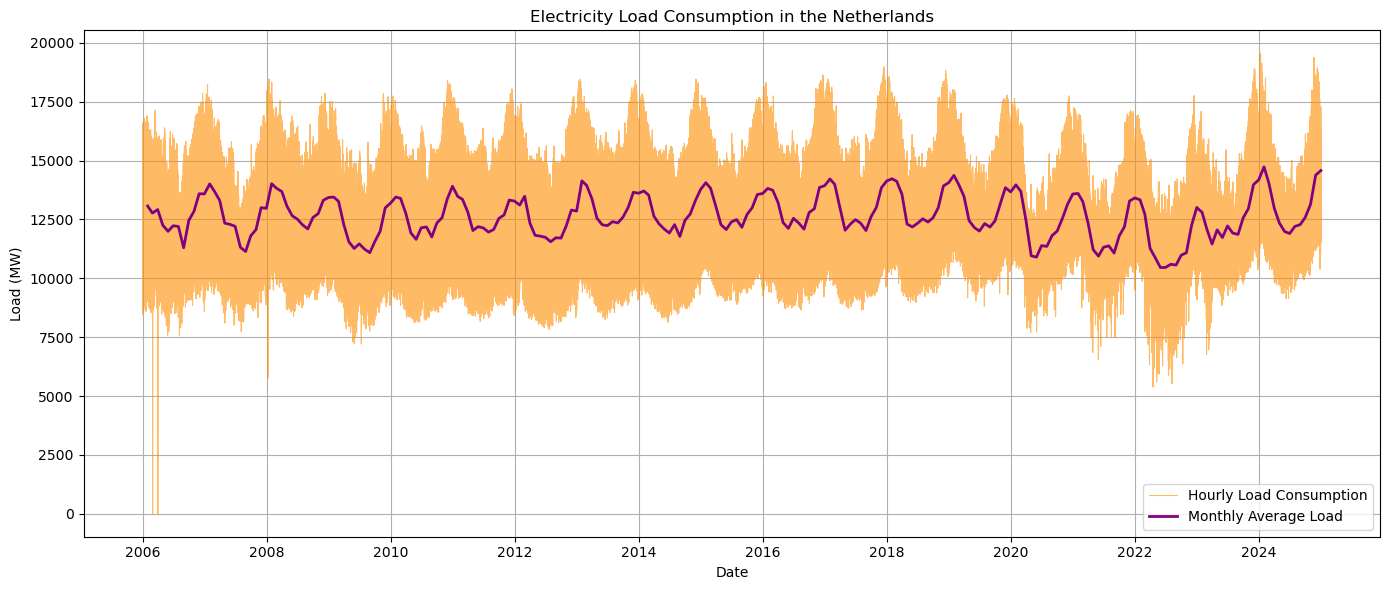

In [96]:
# Calculate monthly average
monthly_load = load_NL.resample('M')['LoadConsumption'].mean()

# Create the figure
plt.figure(figsize=(14, 6))

# Plot original load data (semi-transparent for clarity)
plt.plot(
    load_NL.index,
    load_NL['LoadConsumption'],
    label='Hourly Load Consumption',
    color='darkorange',
    linewidth=0.8,
    alpha=0.6
)

# Plot monthly average load
plt.plot(
    monthly_load.index,
    monthly_load.values,
    label='Monthly Average Load',
    color='purple',
    linewidth=2
)

# Formatting
plt.title('Electricity Load Consumption in the Netherlands')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Optional: save to file
# plt.savefig('load_consumption_overview.png', dpi=300)

plt.show()

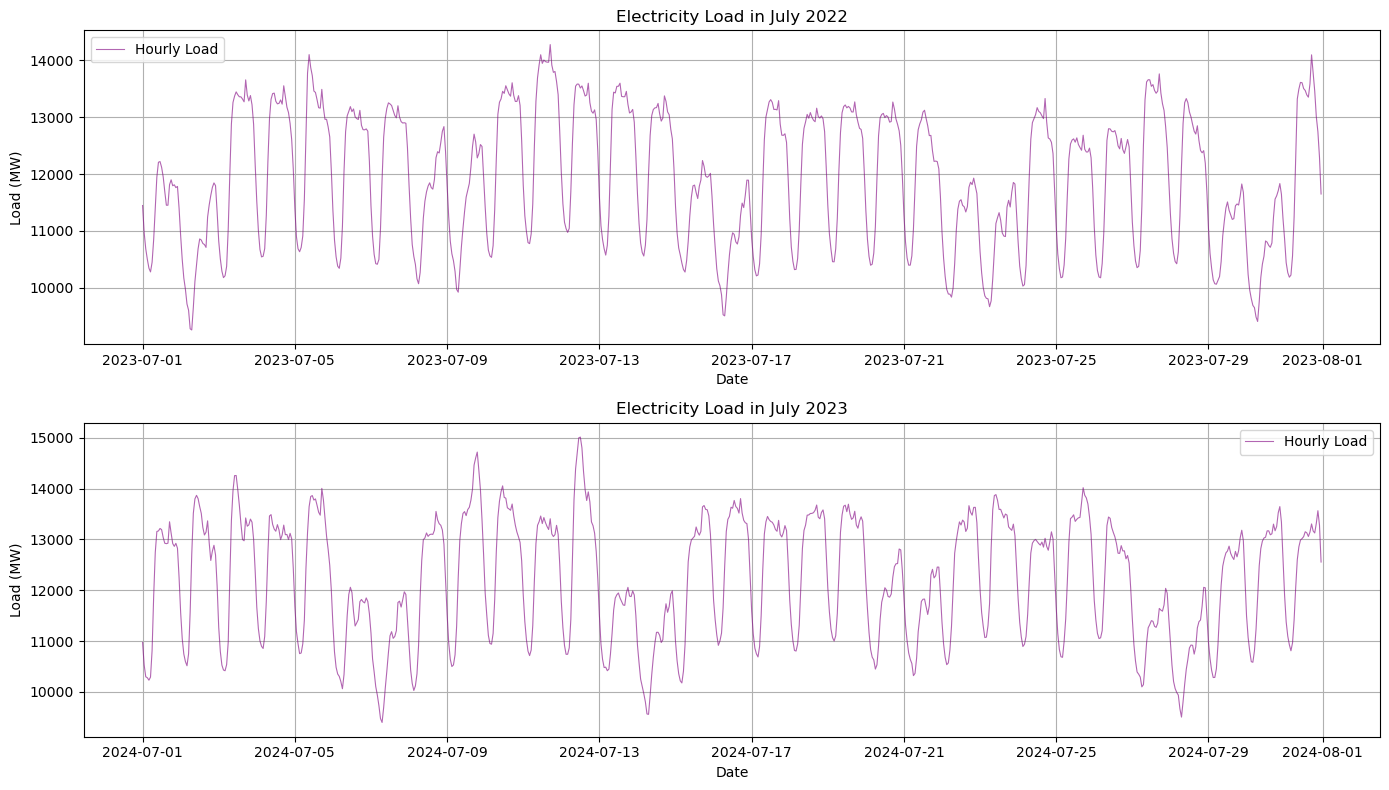

In [105]:
# Filter based on index instead of a 'datetime' column
df_summer_2022_2023 = load_NL[(load_NL.index >= '2023-07-01') & (load_NL.index < '2023-08-01')]
df_summer_2023_2024 = load_NL[(load_NL.index >= '2024-07-01') & (load_NL.index < '2024-08-01')]

# Create styled plot
plt.figure(figsize=(14, 8))

# Subplot for December 2021
plt.subplot(2, 1, 1)
plt.plot(
    df_summer_2022_2023.index, 
    df_summer_2022_2023['LoadConsumption'], 
    label='Hourly Load', 
    color='purple',
    linewidth=0.8,
    alpha=0.6
)
plt.title('Electricity Load in July 2022')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()

# Subplot for December 2022
plt.subplot(2, 1, 2)
plt.plot(
    df_summer_2023_2024.index, 
    df_summer_2023_2024['LoadConsumption'], 
    label='Hourly Load', 
    color='purple',
    linewidth=0.8,
    alpha=0.6
)
plt.title('Electricity Load in July 2023')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()

# Final layout adjustment
plt.tight_layout()
plt.show()


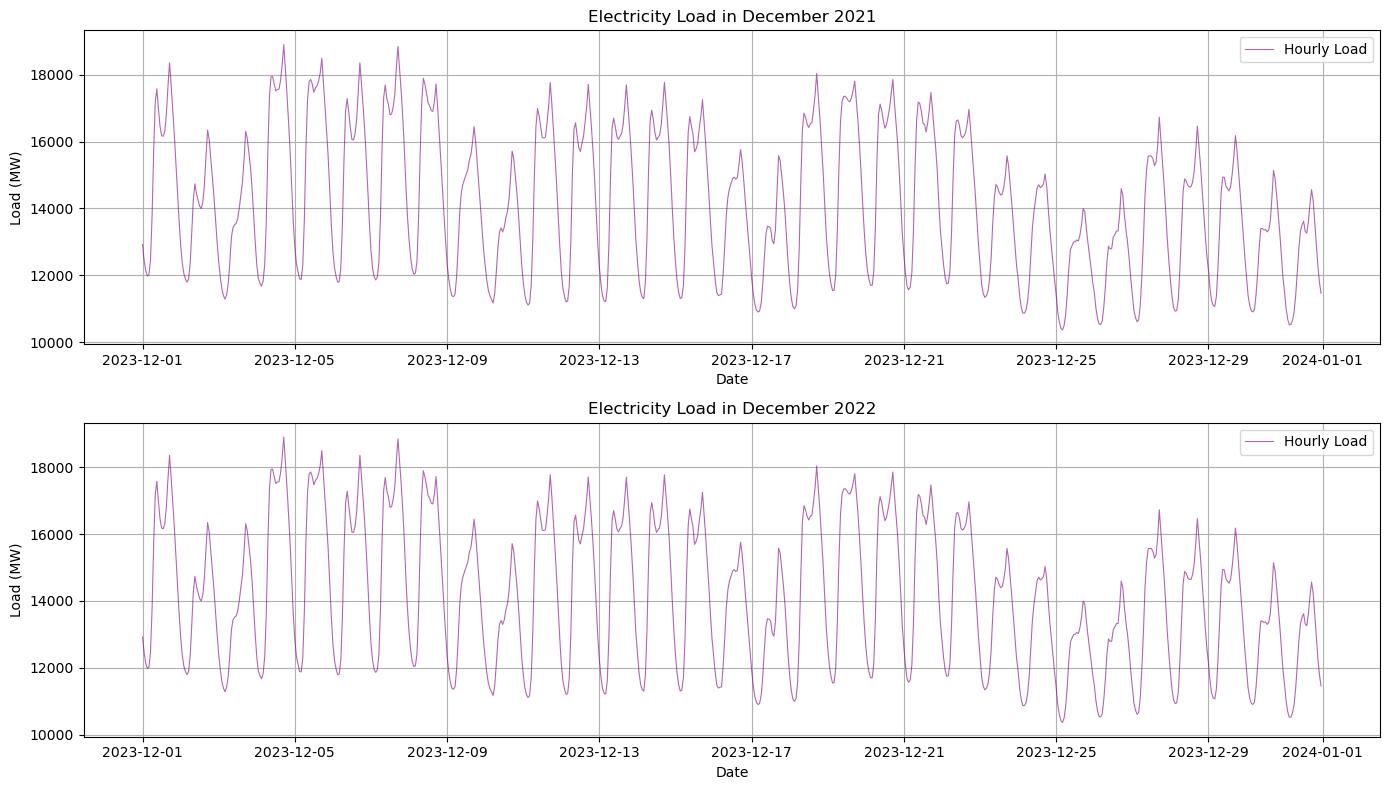

In [103]:
# Filter based on index instead of a 'datetime' column
df_winter_2021_2022 = load_NL[(load_NL.index >= '2023-12-01') & (load_NL.index < '2024-01-01')]
df_winter_2022_2023 = load_NL[(load_NL.index >= '2023-12-01') & (load_NL.index < '2024-01-01')]

# Create styled plot
plt.figure(figsize=(14, 8))

# Subplot for December 2021
plt.subplot(2, 1, 1)
plt.plot(
    df_winter_2021_2022.index, 
    df_winter_2021_2022['LoadConsumption'], 
    label='Hourly Load', 
    color='purple',
    linewidth=0.8,
    alpha=0.6
)
plt.title('Electricity Load in December 2021')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()

# Subplot for December 2022
plt.subplot(2, 1, 2)
plt.plot(
    df_winter_2022_2023.index, 
    df_winter_2022_2023['LoadConsumption'], 
    label='Hourly Load', 
    color='purple',
    linewidth=0.8,
    alpha=0.6
)
plt.title('Electricity Load in December 2022')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()

# Final layout adjustment
plt.tight_layout()
plt.show()


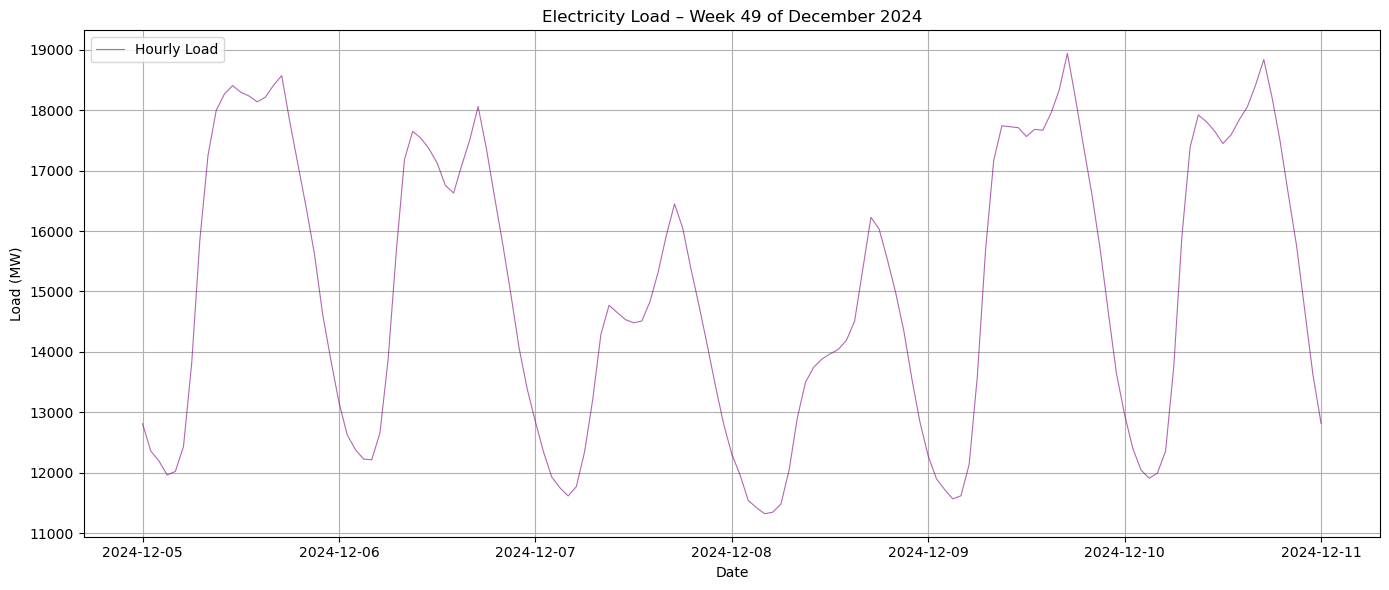

In [106]:
import matplotlib.pyplot as plt

# Filter using the datetime index
df_1_week = load_NL[(load_NL.index >= '2024-12-05') & (load_NL.index <= '2024-12-11')]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    df_1_week.index, 
    df_1_week['LoadConsumption'], 
    label='Hourly Load', 
    color='purple',
    linewidth=0.8,
    alpha=0.6
)
plt.title('Electricity Load – Week 49 of December 2024')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


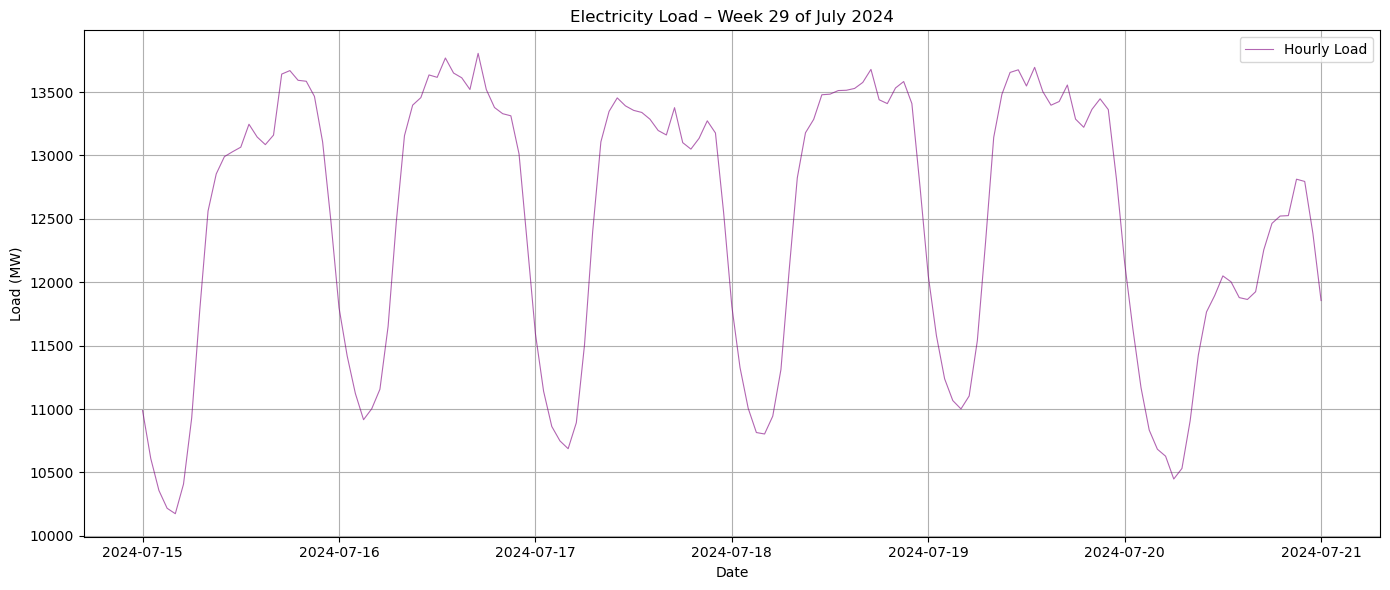

In [112]:
import matplotlib.pyplot as plt

# Filter using the datetime index
df_1_week = load_NL[(load_NL.index >= '2024-07-15') & (load_NL.index <= '2024-07-21')]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    df_1_week.index, 
    df_1_week['LoadConsumption'], 
    label='Hourly Load', 
    color='purple',
    linewidth=0.8,
    alpha=0.6
)
plt.title('Electricity Load – Week 29 of July 2024')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


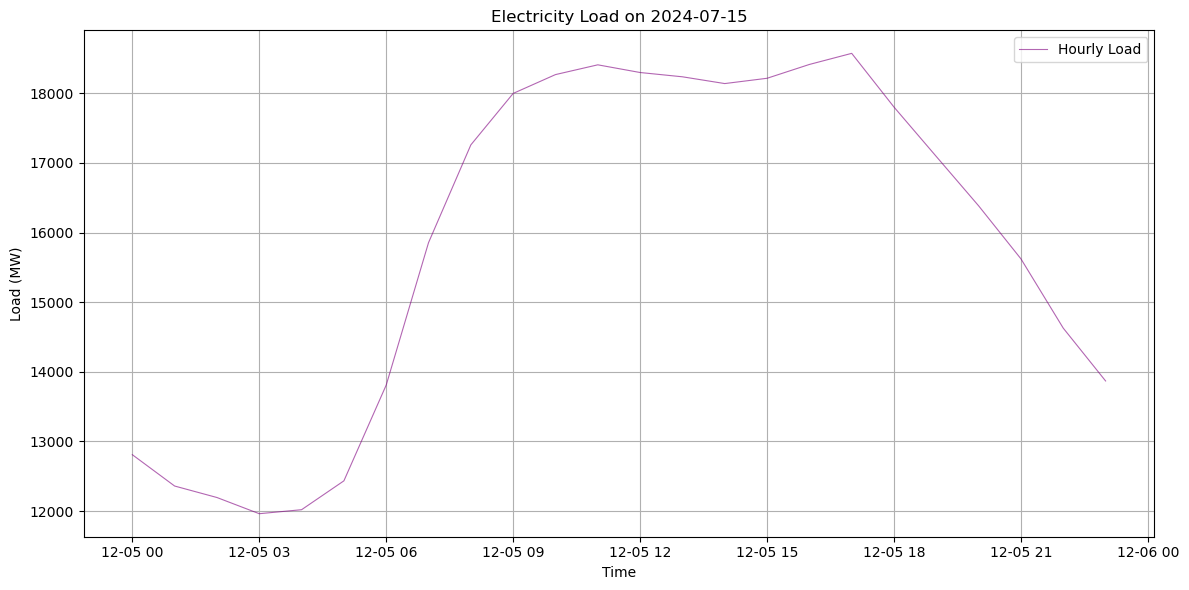

In [113]:
# Filter the specific day using the datetime index
df_1_day = load_NL[(load_NL.index >= '2024-12-05 00:00') & (load_NL.index <= '2024-12-05 23:59')]

# Plot using timestamps on x-axis
plt.figure(figsize=(12, 6))
plt.plot(
    df_1_day.index, 
    df_1_day['LoadConsumption'], 
    label='Hourly Load',
    color='purple',
    linewidth=0.8,
    alpha=0.6
)
plt.title('Electricity Load on 2024-07-15')
plt.xlabel('Time')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


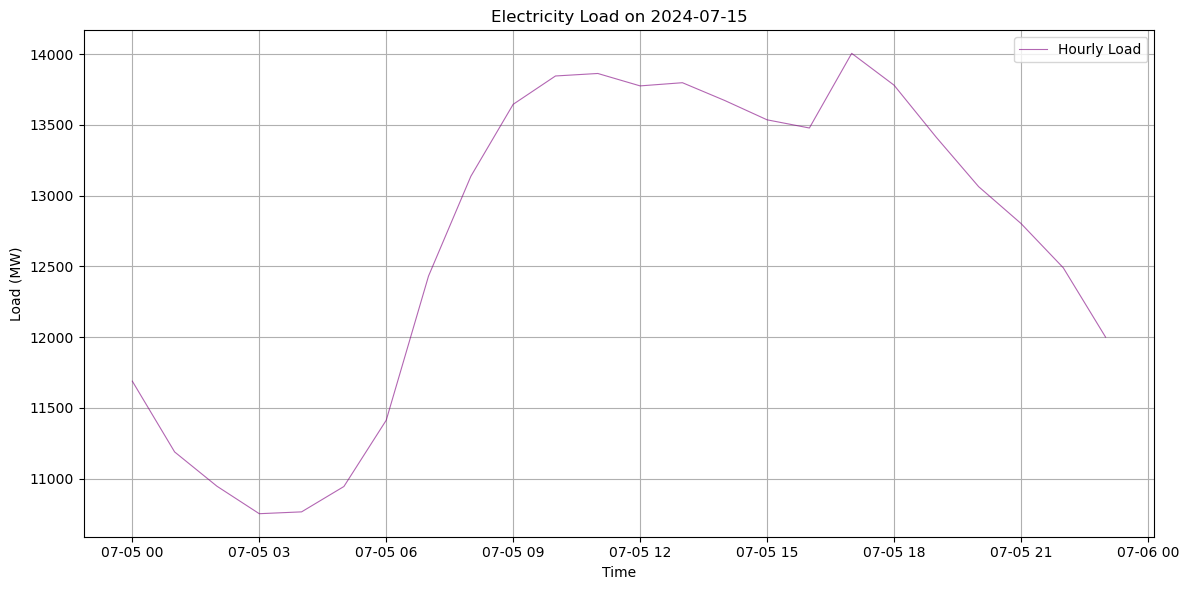

In [114]:
# Filter the specific day using the datetime index
df_1_day = load_NL[(load_NL.index >= '2024-7-05 00:00') & (load_NL.index <= '2024-7-05 23:59')]

# Plot using timestamps on x-axis
plt.figure(figsize=(12, 6))
plt.plot(
    df_1_day.index, 
    df_1_day['LoadConsumption'], 
    label='Hourly Load',
    color='purple',
    linewidth=0.8,
    alpha=0.6
)
plt.title('Electricity Load on 2024-07-15')
plt.xlabel('Time')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Creating a complete dataset to test

In [ ]:
# # Merging all datasets on datetime index using the hourly-aware function
# CompleteDataset = merge_on_hourly_index(load_NL, df_LaborParticipation)
# CompleteDataset = merge_on_hourly_index(CompleteDataset, df_Boughthomes)
# CompleteDataset = merge_on_hourly_index(CompleteDataset, df_ConsumerPriceIndex)
# CompleteDataset = merge_on_hourly_index(CompleteDataset, df_GdpProductionAndSpending)
# CompleteDataset = merge_on_hourly_index(CompleteDataset, df_Commodities)
# CompleteDataset = merge_on_hourly_index(CompleteDataset, energy_prices)
# CompleteDataset = merge_on_hourly_index(CompleteDataset, nat_df_filled)
# CompleteDataset = merge_on_hourly_index(CompleteDataset, weather)

# # Optional: Filter and export final dataset
# CompleteDataset[CompleteDataset.index > '2000-01-01'].to_csv('CompleteDataset.csv')

# # Display a filtered slice for inspection
# CompleteDataset[(CompleteDataset.index > '2000-01-01') & (CompleteDataset.index < '2023-01-01')]


Expanding df1 to hourly intervals...
Expanding df2 to hourly intervals...
Merging on datetime index with method 'inner'
Expanding df1 to hourly intervals...


In [ ]:
import pandas as pd

def infer_resolution(df):
    inferred = pd.infer_freq(df.index)
    return inferred if inferred else "unknown"
def resample_to_hourly(df, reference_index, verbose=True):
    if not df.index.is_unique:
        if verbose:
            print("Index is not unique; aggregating with mean before reindexing.")
        df = df.groupby(df.index).mean(numeric_only=True)

    # Ensure sorted index for clean reindex
    df = df.sort_index()

    return df.reindex(reference_index, method='ffill')


def validate_and_merge_hourly(main_df, other_dfs, verbose=True):
    """
    Parameters:
        main_df (pd.DataFrame): Main hourly dataframe (e.g., load data) with datetime index
        other_dfs (dict): Dictionary of {name: df} where df has datetime index
        verbose (bool): Whether to print warnings and debug info

    Returns:
        Merged and cleaned hourly dataframe
    """
    merged_df = main_df.copy()
    if not isinstance(merged_df.index, pd.DatetimeIndex):
        raise ValueError("main_df must have a DatetimeIndex")

    ref_index = merged_df.index

    for name, df in other_dfs.items():
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError(f"{name} must have a DatetimeIndex")

        res = infer_resolution(df)
        if verbose:
            print(f"{name}: inferred resolution = {res}, shape = {df.shape}")

        if not df.index.is_monotonic_increasing:
            df = df.sort_index()

        # If resolution is lower than hourly, upsample
        if res != "H":
            if verbose:
                print(f"Upsampling {name} to hourly")
            df = resample_to_hourly(df, ref_index)

        # Merge
        merged_df = merged_df.merge(df, left_index=True, right_index=True, how='inner')

    # Deduplicate if needed
    if not merged_df.index.is_unique:
        if verbose:
            print(f"Found {merged_df.index.duplicated().sum()} duplicated timestamps. Grouping by mean.")
        merged_df = merged_df.groupby(merged_df.index).mean(numeric_only=True)

    if verbose:
        print("Final merged shape:", merged_df.shape)
        print("Unique index:", merged_df.index.is_unique)

    return merged_df

# Example main_df
main_df = load_NL  # must have hourly index

# Dictionary of additional dataframes (each must have datetime index)
other_sources = {
    "labor": df_LaborParticipation,
    "homes": df_Boughthomes,
    "cpi": df_ConsumerPriceIndex,
    "gdp": df_GdpProductionAndSpending,
    "commodities": df_Commodities,
    "energy_prices": energy_prices,
    "natgas": nat_df_filled,
    "weather": weather,
}

CompleteDataset = validate_and_merge_hourly(main_df, other_sources)




labor: inferred resolution = h, shape = (194280, 7)
Upsampling labor to hourly
homes: inferred resolution = unknown, shape = (275784, 8)
Upsampling homes to hourly


ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
CompleteDataset.to_csv("CompleteDatasetWithoutProphet.csv")

In [132]:
CompleteDataset.index

DatetimeIndex(['2009-01-01 00:00:00', '2009-01-01 00:00:00',
               '2009-01-01 00:00:00', '2009-01-01 00:00:00',
               '2009-01-01 00:00:00', '2009-01-01 00:00:00',
               '2009-01-01 00:00:00', '2009-01-01 00:00:00',
               '2009-01-01 01:00:00', '2009-01-01 01:00:00',
               ...
               '2020-12-01 19:00:00', '2020-12-01 19:00:00',
               '2020-12-01 20:00:00', '2020-12-01 20:00:00',
               '2020-12-01 21:00:00', '2020-12-01 21:00:00',
               '2020-12-01 22:00:00', '2020-12-01 22:00:00',
               '2020-12-01 23:00:00', '2020-12-01 23:00:00'],
              dtype='datetime64[ns]', length=8640, freq=None)

In [70]:
# CompleteDataset = CompleteDataset.drop(['day_of_week','Year', 'Month', 'Week', 'WeekKey'], axis=1).to_csv('CompleteDataset.csv', index=False)
Create_EDA(CompleteDataset) # Create EDA for CompleteDataset
CompleteDataset.to_csv('CompleteDatasetHourly.csv', index=True)


Amount of days with missing values: LoadConsumption                                  0.0
Beroepsbevolking|Seizoengecorrigeerd             0.0
Werkzame beroepsbevolking|Seizoengecorrigeerd    0.0
Werkloze beroepsbevolking|Seizoengecorrigeerd    0.0
Werkloosheidspercentage|Seizoengecorrigeerd      0.0
                                                ... 
Month                                            0.0
Year                                             0.0
Week                                             0.0
WeekKey                                          0.0
day_of_week                                      0.0
Length: 73, dtype: float64
       LoadConsumption                 date  \
count      8640.000000                 8640   
mean      12320.211941  2014-11-12 20:48:00   
min        7904.000000  2009-01-01 00:00:00   
25%       10616.000000  2011-12-24 06:00:00   
50%       12053.250000  2014-12-16 12:00:00   
75%       13856.562500  2017-12-08 18:00:00   
max       18390.000000  2

# Correlation Analysis

In [72]:
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import pearsonr

# # Calculate correlations with p-values
# Keep only numeric columns
CompleteDataset_numeric = CompleteDataset.select_dtypes(include='number')

# Optional: also drop columns with very few non-NaN values
CompleteDataset_numeric = CompleteDataset_numeric.dropna(axis=1, thresh=10)

# Now run your correlation function safely
correlation_results = calculate_correlations_with_pvalues(CompleteDataset_numeric)


# # Save to CSV
correlation_results.to_csv(
    '/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/processed_data/CompleteCorrelation.csv',
    index=True)


In [73]:
correlation_results

,Correlation,P_Value
Variable,,
LoadConsumption,1.000000,0.000000e+00
Aantal verkochte woningen|Ontwikkeling t.o.v. voorgaande periode,0.294519,1.854375e-172
"Opbouw bbp vanuit de finale bestedingen|Beschikbaar voor finale bestedingen|Bbp, gecorrigeerd voor werkdageneffecten",0.151473,1.367148e-23
Month,0.149362,2.742405e-44
euro per kWh.1,-0.138461,3.022883e-38
...,...,...
"Coal, South African ** | ($/mt)",0.015574,1.477527e-01
euro per m3.1,0.015214,1.573477e-01
Opbouw bbp vanuit de finale bestedingen|Finale bestedingen|Nationale finale bestedingen|Consumptieve bestedingen|Overheid,-0.011081,3.030556e-01


In [74]:
import pandas as pd
import numpy as np
import plotly.express as px

# Load precomputed correlations (exclude self‑correlation)
corr_df = (
    pd.read_csv('/Users/ruben/Documents/GitHub/MsCThesisRubenCuriel2024/Data/processed_data/CompleteCorrelation.csv')
      .query("Variable != 'LoadConsumption'")
)

# Round for display
corr_df[['Correlation','P_Value']] = corr_df[['Correlation','P_Value']].round({'Correlation':2,'P_Value':4})

# Filter significant (p < .05)
sig = corr_df[corr_df['P_Value'] < 0.05]

# Print table of significant correlations
if not sig.empty:
    print("\nSignificant Correlations (p < 0.05):")
    print(sig[['Variable','Correlation','P_Value']].sort_values('Correlation', ascending=False).to_string(index=False))
else:
    print("\nNo significant correlations found.")

# Top 10 positive & negative
top_pos = sig.nlargest(10, 'Correlation')['Variable'].tolist()
top_neg = sig.nsmallest(10, 'Correlation')['Variable'].tolist()

print("\nTop 10 Positive Correlations:", top_pos)
print("Top 10 Negative Correlations:", top_neg)

# Mark significance for plotting
corr_df['Significance'] = np.where(corr_df['P_Value'] < 0.05, 'Significant', 'Not Significant')

# Plotly scatter
fig = px.scatter(
    corr_df,
    x='Correlation',
    y='Variable',
    color='Significance',
    color_discrete_map={'Significant':'green','Not Significant':'red'},
    title='Correlation with LoadConsumption (α = 0.05)',
    hover_data={'P_Value':True},
    category_orders={'Variable': corr_df.sort_values('Correlation')['Variable'].tolist()}
)

fig.update_layout(
    xaxis_title='Correlation Coefficient',
    yaxis_title=None,
    xaxis_range=[-1.1, 1.1],
    height=600
)

fig.update_traces(marker=dict(size=10, opacity=0.7),
                  hovertemplate="<b>%{y}</b><br>Correlation: %{x:.2f}<br>P‑Value: %{customdata[0]:.4f}<extra></extra>")

fig.show()



Significant Correlations (p < 0.05):
                                                                                                                                            Variable  Correlation  P_Value
                                                                                   Aantal verkochte woningen|Ontwikkeling  t.o.v. voorgaande periode         0.29   0.0000
                                                                                                                                               Month         0.15   0.0000
                                Opbouw bbp vanuit de finale bestedingen|Beschikbaar voor finale bestedingen|Bbp, gecorrigeerd voor werkdageneffecten         0.15   0.0000
                                               Opbouw bbp vanuit de finale bestedingen|Beschikbaar voor finale bestedingen|Bruto binnenlands product         0.12   0.0000
                                                                                      Prijsindex verkooppri

In [76]:
# Start from the full CompleteDataset
df_prophet = CompleteDataset.copy()

# Reset index so that datetime becomes a column
df_prophet = df_prophet.reset_index()

# Rename the datetime column to 'ds' and the target variable to 'y'
df_prophet = df_prophet.rename(columns={"index": "ds", "LoadConsumption": "y"})

# Optional: if index had a name already (like 'date'), use that
# df_prophet = df_prophet.rename(columns={"date": "ds", "LoadConsumption": "y"})

# Split into train and test
train_size = int(0.8 * len(df_prophet))
train_data = df_prophet[:train_size]
test_data = df_prophet[train_size:]

# Check it worked
df_prophet.head()


,ds,y,Beroepsbevolking|Seizoengecorrigeerd,Werkzame beroepsbevolking|Seizoengecorrigeerd,Werkloze beroepsbevolking|Seizoengecorrigeerd,Werkloosheidspercentage|Seizoengecorrigeerd,Bruto arbeidsparticipatie|Seizoengecorrigeerd,Netto arbeidsparticipatie|Seizoengecorrigeerd,date,Prijsindex verkoopprijzen|Prijsindex bestaande koopwoningen,...,DailyMeanWindspeed,MaxHourlyMeanWindspeed,HDMaxMeanWindspeed,MinHourlyMeanWindspeed,HDMinMeanWindspeed,Month,Year,Week,WeekKey,day_of_week
0,2009-01-01,11597.0,9029,8594,434,"4,8","73,1","69,6",2009-01-01,120.1,...,1.6,2.0,9,1.0,1,1,2009,1,200901,Thursday
1,2009-01-01,11597.0,9029,8594,434,"4,8","73,1","69,6",2009-01-01,120.1,...,1.6,2.0,9,1.0,1,1,2009,1,200901,Thursday
2,2009-01-01,11597.0,9029,8594,434,"4,8","73,1","69,6",2009-01-01,120.1,...,1.6,2.0,9,1.0,1,1,2009,1,200901,Thursday
3,2009-01-01,11597.0,9029,8594,434,"4,8","73,1","69,6",2009-01-01,120.1,...,1.6,2.0,9,1.0,1,1,2009,1,200901,Thursday
4,2009-01-01,11597.0,9029,8594,434,"4,8","73,1","69,6",2009-01-01,115.6,...,1.6,2.0,9,1.0,1,1,2009,1,200901,Thursday


In [77]:
def initialize_prophet(regressors, add_seasonality, fourier_weekly, fourier_annual):
    """
    Initialize prophet. Either with specified seasonalities or default. 
    Add regressors if any are entered. 
    """
    if add_seasonality:
        model = Prophet(
            daily_seasonality=False,
            weekly_seasonality=fourier_weekly,
            yearly_seasonality=fourier_annual,
        )

    else:
        model = Prophet()
        
    if len(regressors) > 0:
        for regressor in regressors:
            model.add_regressor(regressor)
    
    return model

def run_model(train, test, regressors, add_seasonality, fourier_weekly, fourier_annual):
    """
    Run model.
    Give predictions.
    Calculate RMSE.
    """

    # intialize model
    model = initialize_prophet(regressors, add_seasonality, fourier_weekly, fourier_annual)

    # fit model
    model.fit(train)

    # predict with model 
    forecast = model.predict(test)
    forecast['yhat_rounded'] = forecast['yhat'].apply(lambda x: math.floor(x))

    # calculate rmse
    rmse = sqrt(mean_squared_error(test['y'], forecast['yhat_rounded'][-len(test):]))
    
    corr, p_value = pearsonr(y_test, predictions)
    print(f'Correlation: {corr} and p-value: {p_value} on Test Data')
    return rmse

12:26:41 - cmdstanpy - INFO - Chain [1] start processing
12:26:41 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 1169.185436431714
Correlation: 0.8077262239794267 and p-value: 0.0 on Test Data


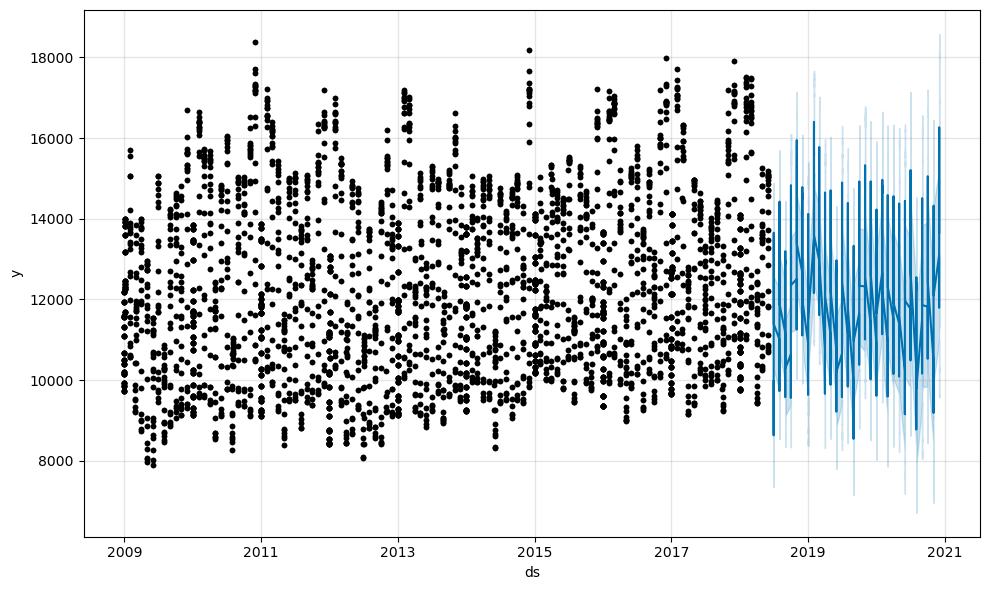

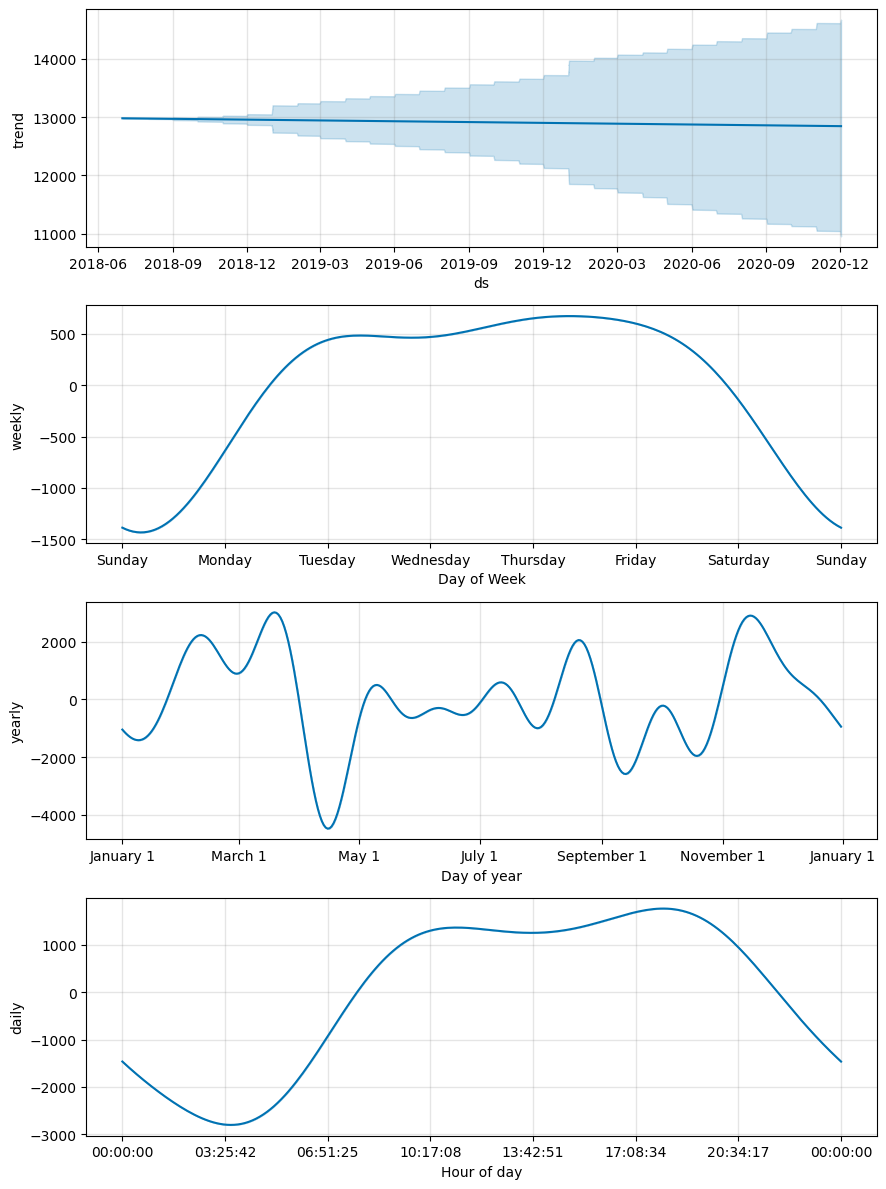

In [78]:
# intialize model
model = initialize_prophet(regressors=[], add_seasonality=False, fourier_weekly=0, fourier_annual=0)

# fit model
model.fit(train_data)

# predict with model 
forecast = model.predict(test_data)
forecast['yhat_rounded'] = forecast['yhat'].apply(lambda x: math.floor(x))

# calculate rmse
print("RMSE:", sqrt(mean_squared_error(test_data['y'], forecast['yhat_rounded'][-len(test_data):])))
corr, p_value = pearsonr(test_data['y'], forecast['yhat_rounded'][-len(test_data):])
print(f'Correlation: {corr} and p-value: {p_value} on Test Data')

# plot
fig1 = model.plot(forecast)

fig2 = model.plot_components(forecast)

12:26:51 - cmdstanpy - INFO - Chain [1] start processing
12:26:51 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 1200.1559378503846
Correlation: 0.7794507734454147 and p-value: 0.0 on Test Data


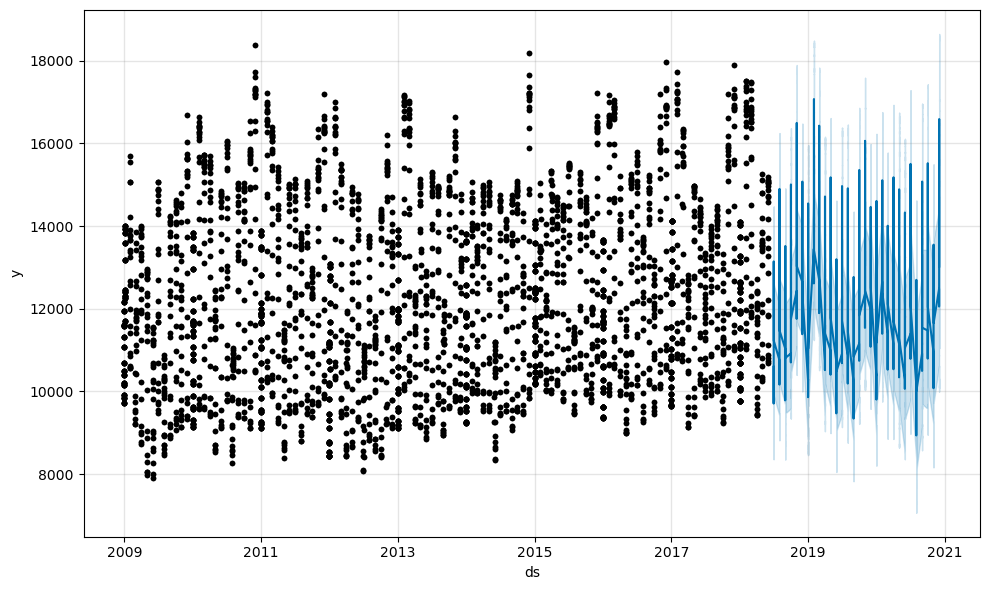

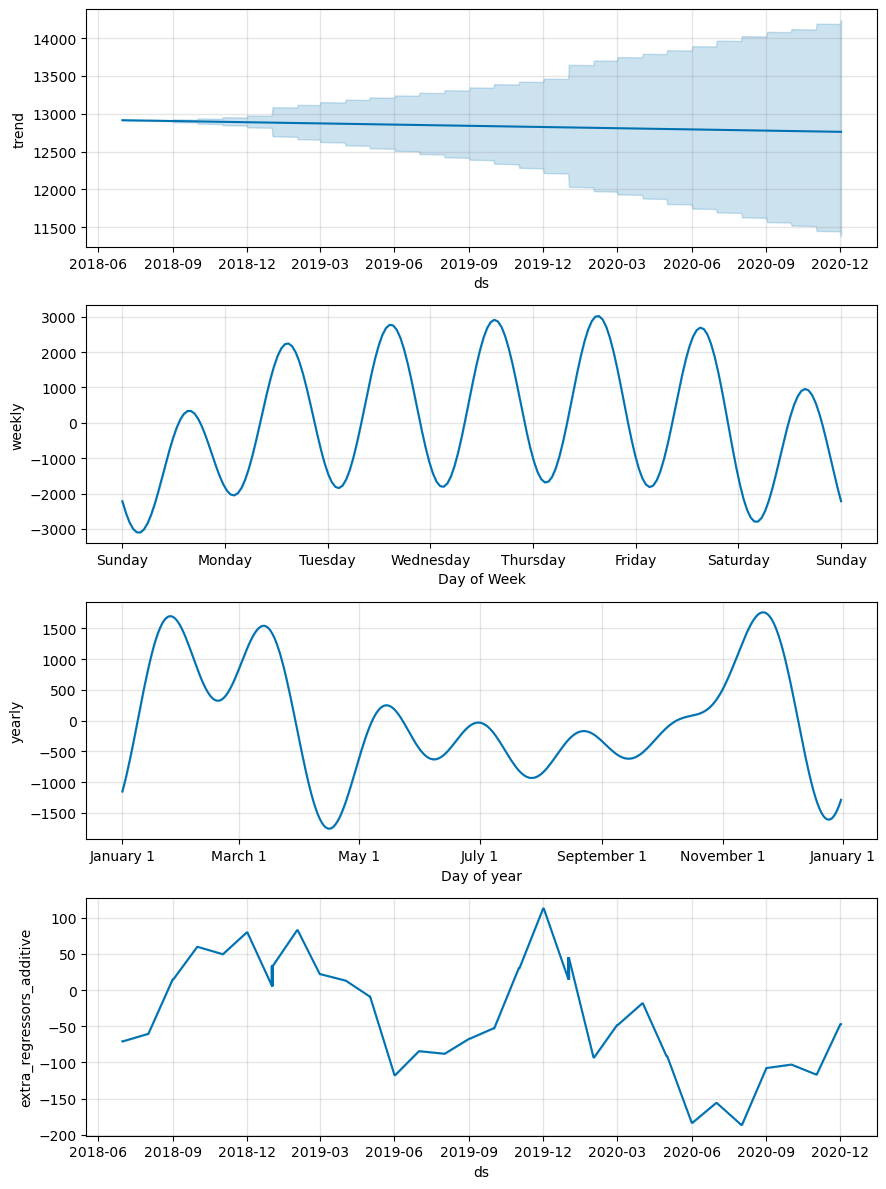

In [79]:
# intialize model
model = initialize_prophet(
    regressors=top_neg[:3],
    add_seasonality=True, 
    fourier_weekly=7, 
    fourier_annual=7
)

# fit model
model.fit(train_data)

# predict with model 
forecast = model.predict(test_data)
forecast['yhat_rounded'] = forecast['yhat'].apply(lambda x: math.floor(x))

# calculate rmse
print("RMSE:", sqrt(mean_squared_error(test_data['y'], forecast['yhat_rounded'][-len(test_data):])))
corr, p_value = pearsonr(test_data['y'], forecast['yhat_rounded'][-len(test_data):])
print(f'Correlation: {corr} and p-value: {p_value} on Test Data')

# plot
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

12:28:27 - cmdstanpy - INFO - Chain [1] start processing
12:28:27 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 1139.304061810474
Correlation: 0.8008083771983462 and p-value: 4.193491134513261e-194 on Test Data


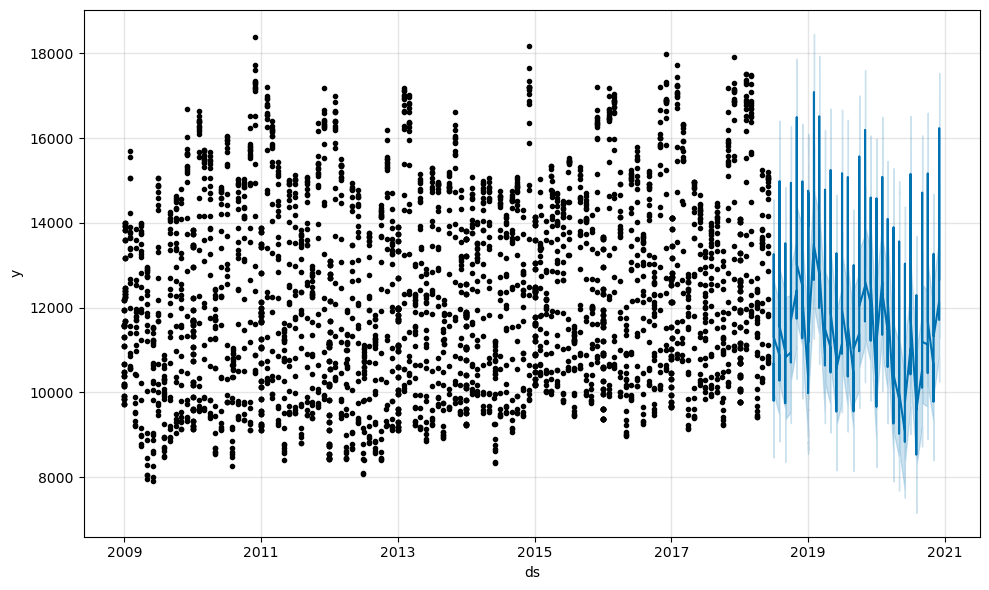

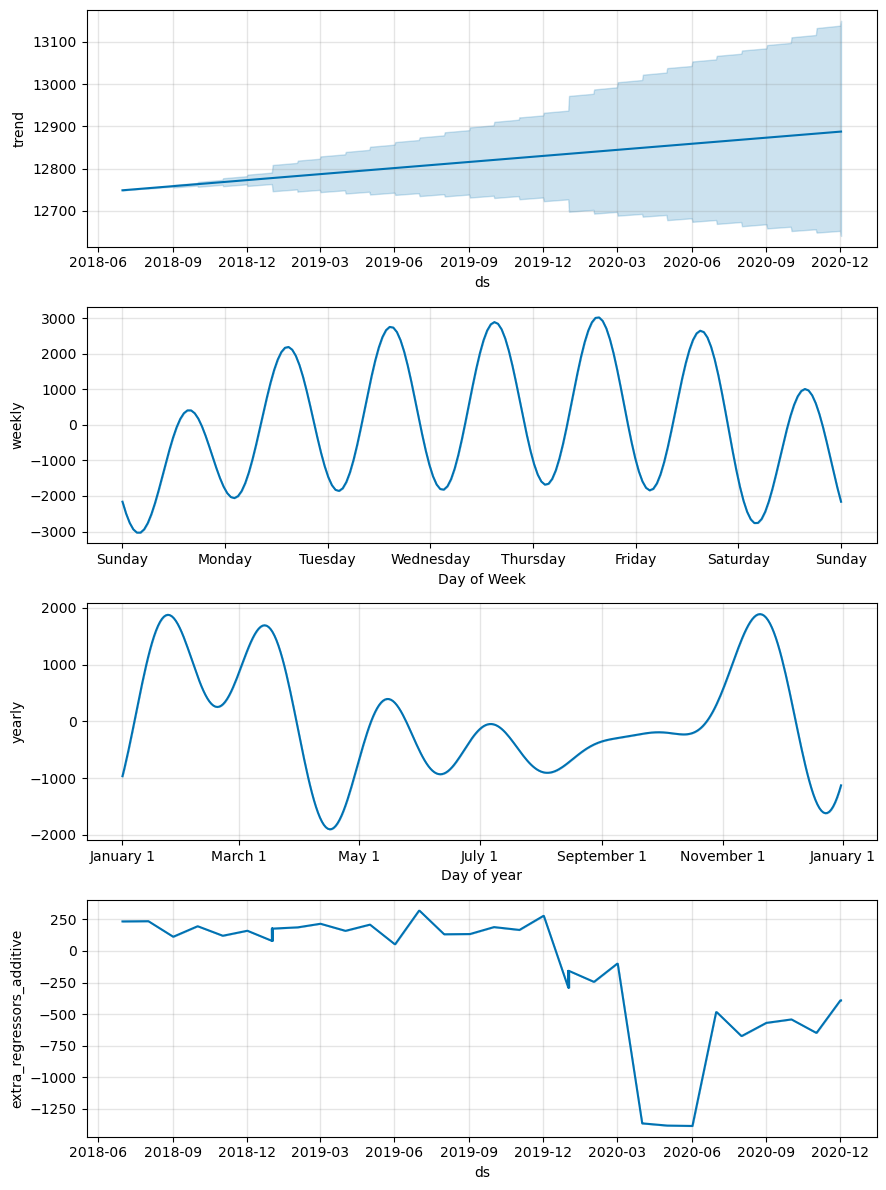

In [82]:
# intialize model
model = initialize_prophet(
    regressors=top_pos[:2],
    add_seasonality=True, 
    fourier_weekly=7, 
    fourier_annual=7
)

# fit model
model.fit(train_data)

# predict with model 
forecast = model.predict(test_data)
forecast['yhat_rounded'] = forecast['yhat'].apply(lambda x: math.floor(x))

# calculate rmse
print("RMSE:", sqrt(mean_squared_error(test_data['y'], forecast['yhat_rounded'][-len(test_data):])))
corr, p_value = pearsonr(test_data['y'], forecast['yhat_rounded'][-len(test_data):])
print(f'Correlation: {corr} and p-value: {p_value} on Test Data')

# plot
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

12:28:48 - cmdstanpy - INFO - Chain [1] start processing
12:28:48 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 1136.4465537645842
Correlation: 0.802, p-value: 7.030e-195 on Test Data


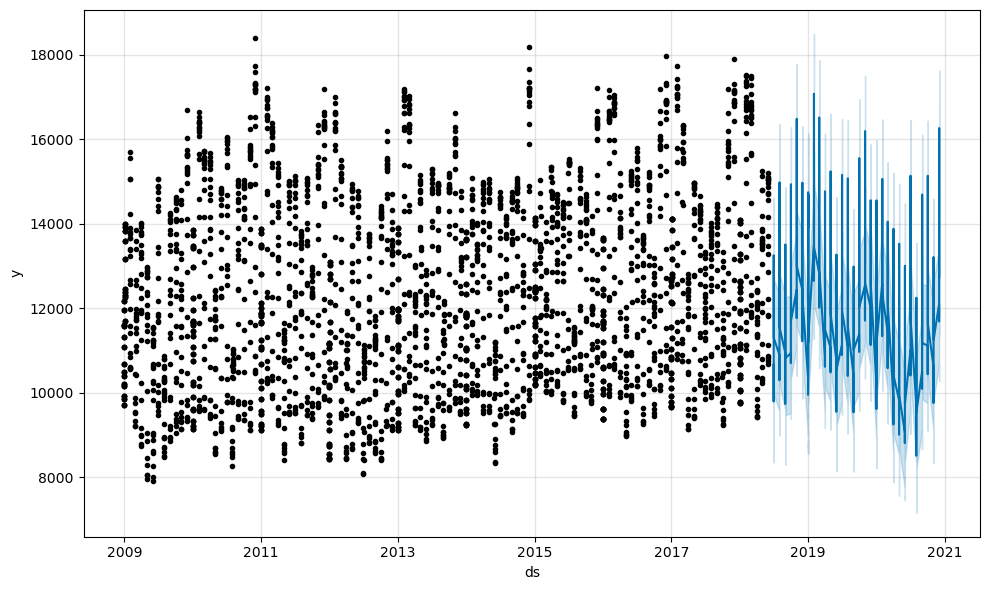

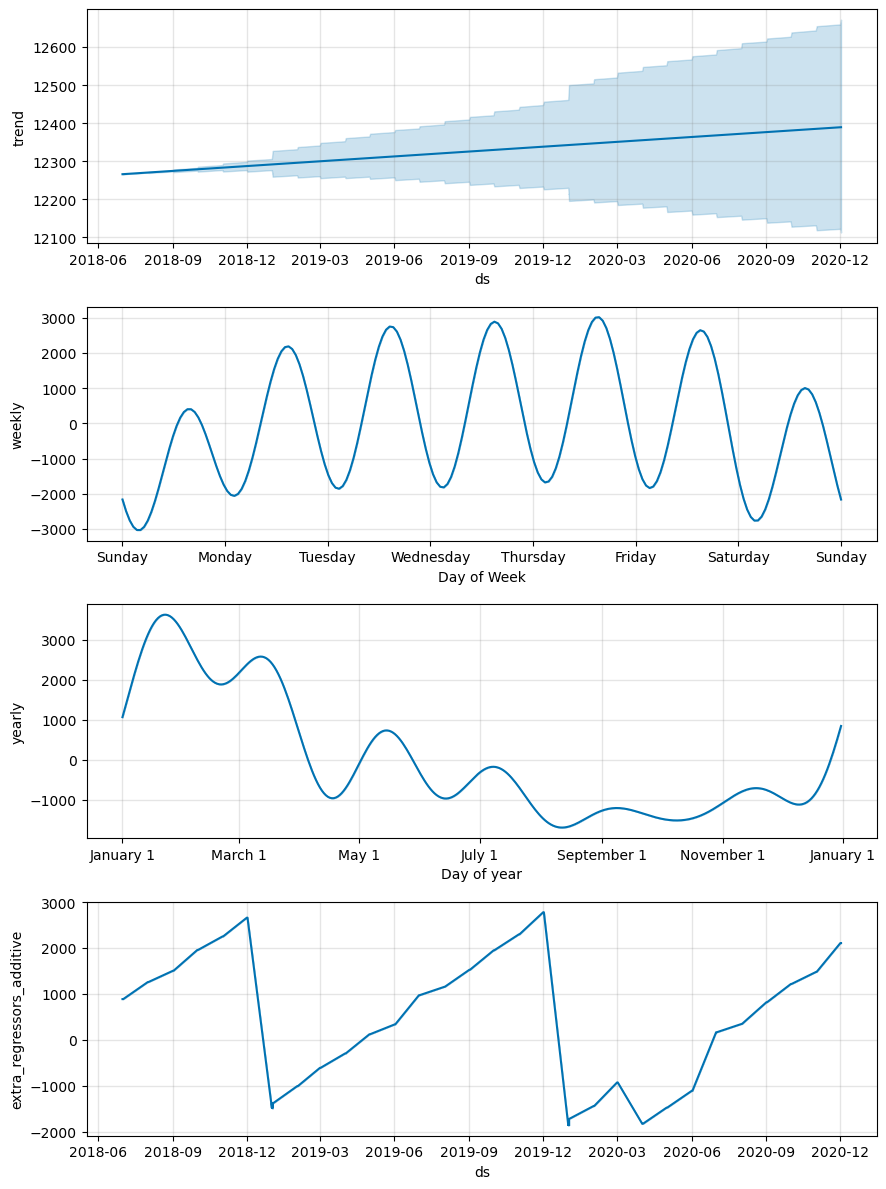

In [83]:
# Ensure df_prophet is correctly built
df_prophet = (
    CompleteDataset
    .reset_index()
    .rename(columns={"index": "ds", "LoadConsumption": "y"})
)

# Drop any NaNs from key columns
required_cols = ['ds', 'y'] + top_pos[:3]  # 'ds', 'y', and your regressors
df_prophet = df_prophet.dropna(subset=required_cols)

# Train/test split
train_size = int(0.8 * len(df_prophet))
train_data = df_prophet[:train_size]
test_data = df_prophet[train_size:]

# Initialize and train model
model = initialize_prophet(
    regressors=top_pos[:3],
    add_seasonality=True,
    fourier_weekly=7,
    fourier_annual=7
)
model.fit(train_data)

# Forecast
forecast = model.predict(test_data)
forecast['yhat_rounded'] = forecast['yhat'].apply(lambda x: math.floor(x))

# Evaluation
print("RMSE:", sqrt(mean_squared_error(test_data['y'], forecast['yhat_rounded'])))
corr, p_value = pearsonr(test_data['y'], forecast['yhat_rounded'])
print(f'Correlation: {corr:.3f}, p-value: {p_value:.3e} on Test Data')

# Plotting
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)


In [84]:
Create_EDA(CompleteDataset)

Amount of days with missing values: LoadConsumption                                  0.0
Beroepsbevolking|Seizoengecorrigeerd             0.0
Werkzame beroepsbevolking|Seizoengecorrigeerd    0.0
Werkloze beroepsbevolking|Seizoengecorrigeerd    0.0
Werkloosheidspercentage|Seizoengecorrigeerd      0.0
                                                ... 
Month                                            0.0
Year                                             0.0
Week                                             0.0
WeekKey                                          0.0
day_of_week                                      0.0
Length: 73, dtype: float64
       LoadConsumption                 date  \
count      8640.000000                 8640   
mean      12320.211941  2014-11-12 20:48:00   
min        7904.000000  2009-01-01 00:00:00   
25%       10616.000000  2011-12-24 06:00:00   
50%       12053.250000  2014-12-16 12:00:00   
75%       13856.562500  2017-12-08 18:00:00   
max       18390.000000  2

Evaluation Results:
  RMSE : 1136.49
  MAPE : 7.16%
  R²   : 0.594
  Pearson Correlation: 0.802 (p = 7.049e-195)


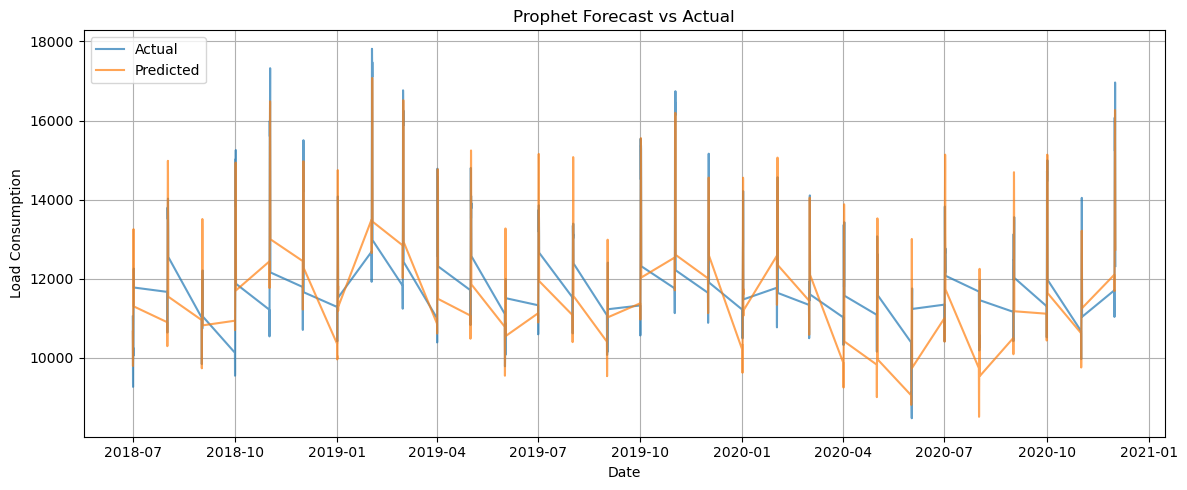

Evaluation Results:
  RMSE : 1136.45
  MAPE : 7.16%
  R²   : 0.594
  Pearson Correlation: 0.802 (p = 7.030e-195)


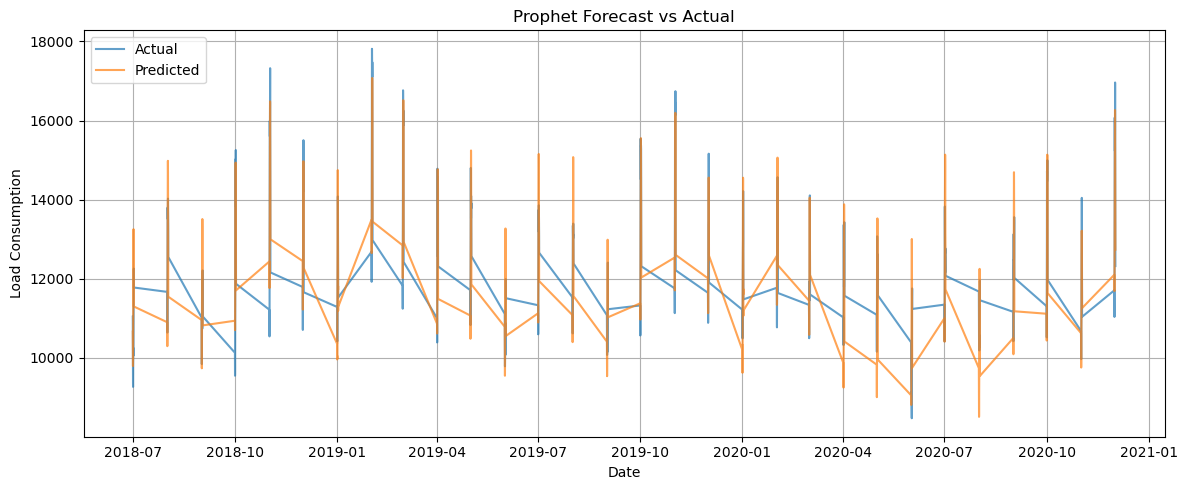

In [85]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from scipy.stats import pearsonr

def evaluate_prophet_forecast(test_df, forecast_df, use_rounded=False, plot=True):
    """
    Evaluate a Prophet forecast against test data.
    
    Parameters:
    - test_df: original test DataFrame (must include 'y' and 'ds')
    - forecast_df: Prophet output from model.predict()
    - use_rounded: whether to evaluate 'yhat_rounded' instead of 'yhat'
    - plot: whether to show actual vs predicted plot

    Returns:
    - summary_df: DataFrame with metrics
    """
    # Extract y_true and y_pred
    y_true = test_df['y'].values
    y_pred = forecast_df['yhat_rounded'].values if use_rounded else forecast_df['yhat'].values

    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    corr, pval = pearsonr(y_true, y_pred)

    # Print results
    print("Evaluation Results:")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R²   : {r2:.3f}")
    print(f"  Pearson Correlation: {corr:.3f} (p = {pval:.3e})")

    # Plot forecast vs actual
    if plot:
        plt.figure(figsize=(12, 5))
        plt.plot(test_df['ds'], y_true, label='Actual', alpha=0.7)
        plt.plot(test_df['ds'], y_pred, label='Predicted', alpha=0.7)
        plt.title("Prophet Forecast vs Actual")
        plt.xlabel("Date")
        plt.ylabel("Load Consumption")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Create results summary as DataFrame
    summary_df = pd.DataFrame({
        "RMSE": [rmse],
        "MAPE (%)": [mape],
        "R²": [r2],
        "Pearson Correlation": [corr],
        "p-value": [pval],
        "Used Rounded": [use_rounded]
    })

    return summary_df

# Example usage:
results = evaluate_prophet_forecast(test_data, forecast, use_rounded=False)
results_rounded = evaluate_prophet_forecast(test_data, forecast, use_rounded=True)


In [115]:
# Ensure forecast DataFrame has datetime column as index
prophet_output = forecast[['ds', 'yhat']].copy()
prophet_output = prophet_output.rename(columns={"yhat": "ProphetForecast"})
prophet_output.set_index('ds', inplace=True)

# Align index type (just in case)
prophet_output.index = pd.to_datetime(prophet_output.index)
CompleteDataset.index = pd.to_datetime(CompleteDataset.index)

# Join Prophet forecasts into CompleteDataset
CompleteDataset_with_prophet = CompleteDataset.join(prophet_output, how='left')

# Check result
print("New shape:", CompleteDataset_with_prophet.shape)
print("Columns:", CompleteDataset_with_prophet.columns[-5:])  # show last few columns
CompleteDataset_with_prophet.tail()

CompleteDatasetWithoutProphet = CompleteDataset

CompleteDatasetWithoutProphet.to_csv('CompleteDatasetWithoutProphet.csv', index=True)


New shape: (9792, 74)
Columns: Index(['Year', 'Week', 'WeekKey', 'day_of_week', 'ProphetForecast'], dtype='object')


In [87]:
CompleteDataset_with_prophet.to_csv('CompleteDatasetWithProphet.csv', index=True)

In [88]:
len(CompleteDataset_with_prophet)

9792

/Users/ruben/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 166541.
  res = hypotest_fun_out(*samples, **kwds)


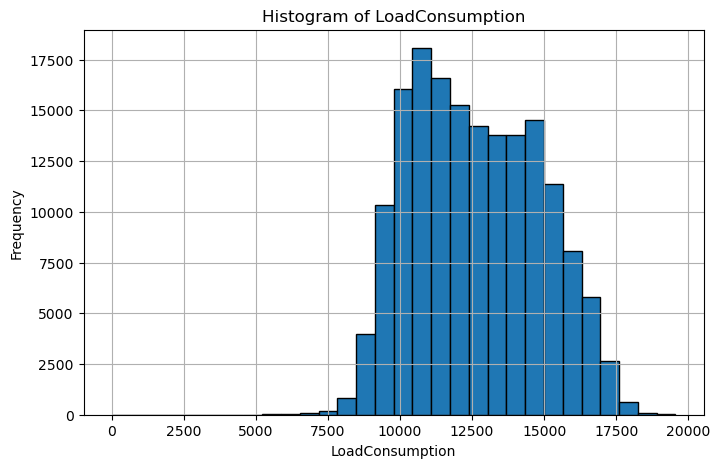

Shapiro–Wilk statistic: 0.9788, p-value: 0.0000


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro

def shapiro_wilk_test_with_histogram(column_name, filepath='CompleteDatasetHourly.csv'):
    """
    Load the CSV at `filepath`, extract the specified column, perform a Shapiro–Wilk test for normality,
    and display a histogram of the data.

    Parameters:
    - column_name (str): Name of the column in the CSV to test.
    - filepath (str): Path to the CSV file. Defaults to 'CompleteDatasetHourly.csv'.

    Returns:
    - stat (float): The Shapiro–Wilk test statistic.
    - p_value (float): The p-value for the test.
    """
    # Load the dataset
    df = pd.read_csv(filepath)

    # Check if the column exists
    if column_name not in df.columns:
        raise KeyError(f"Column '{column_name}' not found in {filepath}")

    # Extract the column values and drop NA
    data = df[column_name].dropna().values

    # Ensure enough data points
    if len(data) < 3:
        raise ValueError("Shapiro–Wilk test requires at least 3 non-NA values.")

    # Perform the Shapiro–Wilk test
    stat, p_value = shapiro(data)

    # Plot histogram
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=30, edgecolor='black')
    plt.title(f"Histogram of {column_name}")
    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    return stat, p_value

# Example usage:
statistic, pval = shapiro_wilk_test_with_histogram('LoadConsumption')
print(f"Shapiro–Wilk statistic: {statistic:.4f}, p-value: {pval:.4f}")


In [4]:
selected_features = [
    "DailyPrecipitation",
    "MaxHourlyPrecipitation",
    "HDMaxPrecipitation",
    "DailyMeanTemperature",
    "HourlyMinTemperature",
    "HDMinTemperature",
    "HourlyMaxTemperature",
    "Month",
    "Week",
    "euro per m3",
    "euro per kWh.1",
    "Werkzame beroepsbevolking|Seizoengecorrigeerd",
    "euro per kWh.2",
    "Beroepsbevolking|Seizoengecorrigeerd",
    "euro per m3.1",
    "CPI | 2015 = 100",
    "Opbouw bbp vanuit de finale bestedingen|Finale bestedingen|Nationale finale bestedingen|Consumptieve bestedingen|Huishoudens",
    "Opbouw bbp vanuit de finale bestedingen|Finale bestedingen|Nationale finale bestedingen|Bruto investeringen in vaste activa|Overheid",
    "Natural gas, US | ($/mmbtu)"
]

print(selected_features)

['DailyPrecipitation', 'MaxHourlyPrecipitation', 'HDMaxPrecipitation', 'DailyMeanTemperature', 'HourlyMinTemperature', 'HDMinTemperature', 'HourlyMaxTemperature', 'Month', 'Week', 'euro per m3', 'euro per kWh.1', 'Werkzame beroepsbevolking|Seizoengecorrigeerd', 'euro per kWh.2', 'Beroepsbevolking|Seizoengecorrigeerd', 'euro per m3.1', 'CPI | 2015 = 100', 'Opbouw bbp vanuit de finale bestedingen|Finale bestedingen|Nationale finale bestedingen|Consumptieve bestedingen|Huishoudens', 'Opbouw bbp vanuit de finale bestedingen|Finale bestedingen|Nationale finale bestedingen|Bruto investeringen in vaste activa|Overheid', 'Natural gas, US | ($/mmbtu)']


In [5]:
for feature in selected_features:
    statistic, pval = shapiro_wilk_test_with_histogram(feature)
    print(f"Shapiro–Wilk statistic: {statistic:.4f}, p-value: {pval:.4f}")

NameError: name 'shapiro_wilk_test_with_histogram' is not defined

In [7]:
df_selected_features = pd.read_csv('CompleteDatasetHourly.csv')[selected_features]

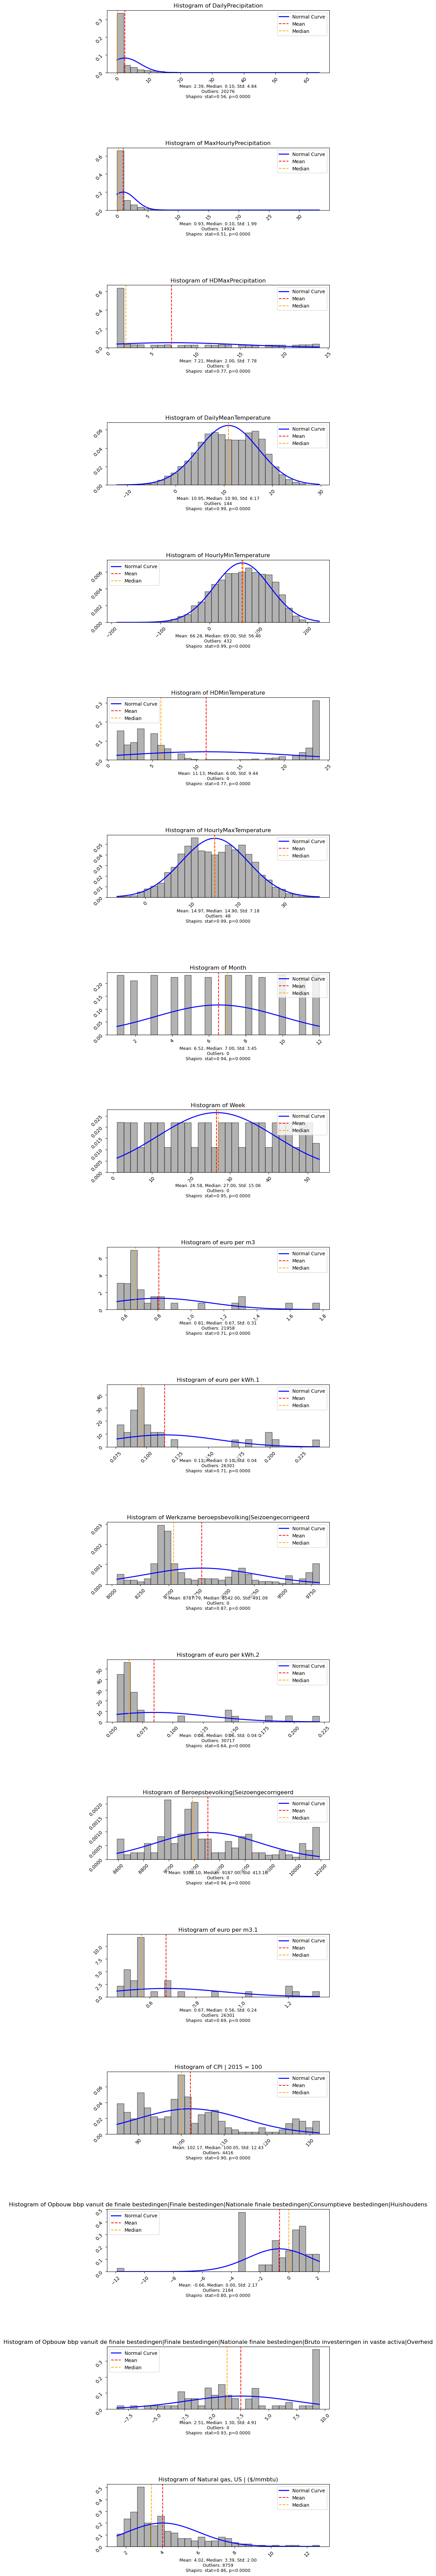

In [14]:
Create_Hist_Normal_Plot_With_Stats_Outliers(df_selected_features)

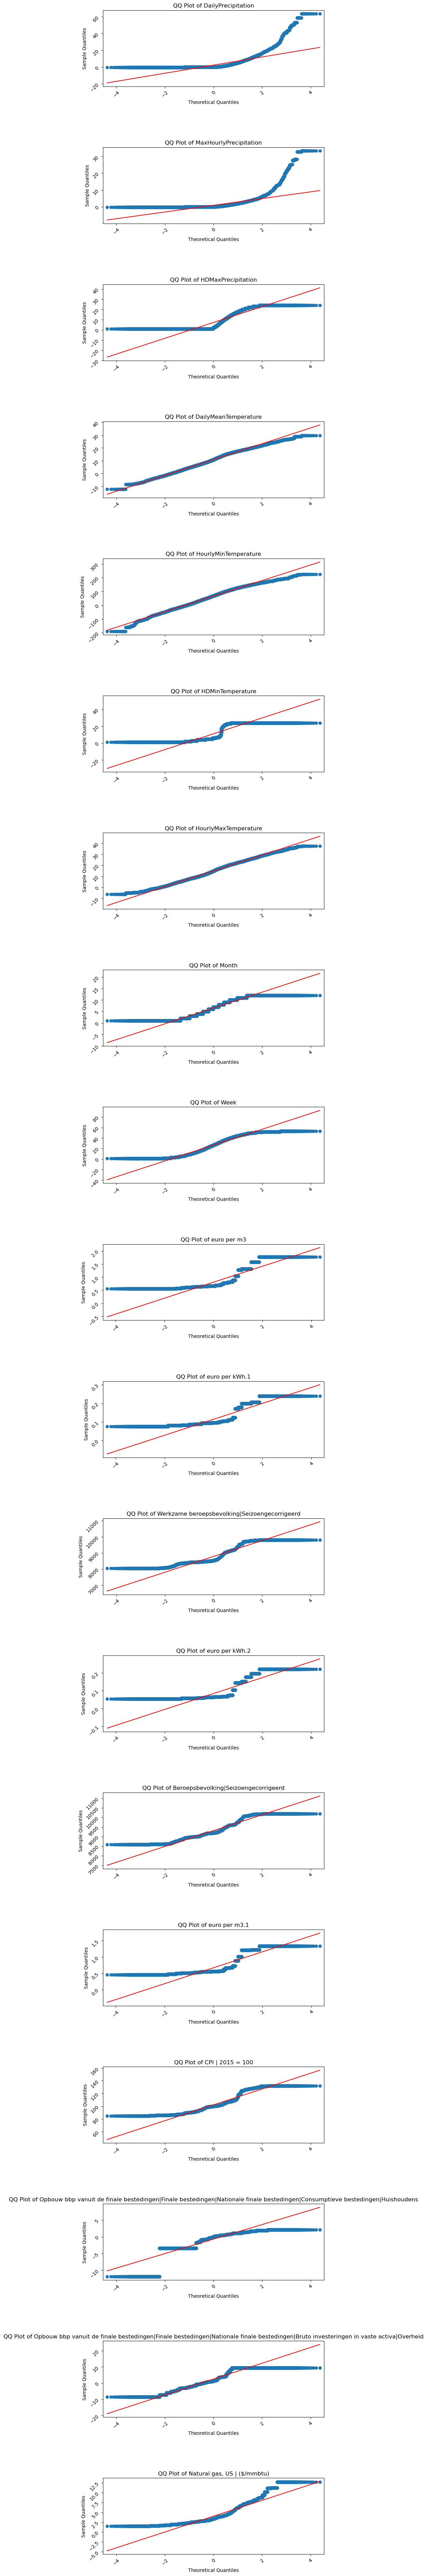

In [13]:
Create_QQ_Plot(df_selected_features)